# Проект: Комплексный анализ платежей донаторов благотворительного фонда

**Цель проекта:** Провести аналитическое исследование исторических данных о пожертвованиях, определить ключевые закономерности поведения донаторов, оценить эффективность регулярных подписок и сформулировать практические рекомендации для увеличения объема регулярных пожертвований и удержания донаторов.

## 1. Импорт библиотек и загрузка данных

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
import sqlite3

In [2]:
# Создание датафрема
subscriptions = pd.read_csv('G:\Мой диск\Обучение\Яндекс.Практикум\Мастерская_Марафон добра\Subscription_analysis_dashbord\encoded_Подписки Cloud Payments 18-06.csv', 
                            sep=';',
                            encoding='utf-8')

In [3]:
# Просмотр первых строк
display(subscriptions.head())

,ID,Дата/время создания,Статус,Сумма,Валюта,Периодичность,Описание,ID плательщика,Кол-во платежей,Дата/время последнего платежа,Дата/время следующего платежа
0,sc_5fd0defafe7ff468dbd3257da445c,18.06.2026 08:39:25,Активна,"1000,00",₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_41ef2e0fdbe2,0,NaN,18.07.2026 08:39:24
1,sc_fb4115049bb199106b401cb66c8bb,17.06.2026 20:57:39,Активна,"100,00",₽,Раз в месяц,Благотворительное пожертвование,PID_34f44fc59dc0,0,NaN,17.07.2026 20:57:39
2,sc_1dad551bda204a1c1ce3a60573458,17.06.2026 20:35:25,Активна,"100,00",₽,Раз в месяц,Благотворительное пожертвование,PID_1070551ebf1b,0,NaN,17.07.2026 20:35:25
3,sc_9c512c6a7880f7cceb309c654c7ef,16.06.2026 20:37:05,Активна,"500,00",₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_cd9879f83789,0,NaN,16.07.2026 20:37:05
4,sc_b1911b7fb5bd247c6c40f25707aed,16.06.2026 15:43:23,Активна,"100,00",₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_6bf236df9e02,0,NaN,16.07.2026 15:43:22


In [4]:
# Просмотр информации
display(subscriptions.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42806 entries, 0 to 42805
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   ID                             42806 non-null  object
 1   Дата/время создания            42806 non-null  object
 2   Статус                         42806 non-null  object
 3   Сумма                          42806 non-null  object
 4   Валюта                         42806 non-null  object
 5   Периодичность                  42806 non-null  object
 6   Описание                       42806 non-null  object
 7   ID плательщика                 42806 non-null  object
 8   Кол-во платежей                42806 non-null  int64 
 9   Дата/время последнего платежа  28537 non-null  object
 10  Дата/время следующего платежа  6528 non-null   object
dtypes: int64(1), object(10)
memory usage: 3.6+ MB


None

## 2. Исследовательский анализ данных (EDA) и проверка качества данных

In [5]:
# Создаем копию данных, чтобы не испортить исходные
df = subscriptions.copy()

In [6]:
# Проверка на пропуски в ключевых столбцах
missing_data = df.isnull().sum()
print("Пропуски в данных:")
print(missing_data[missing_data > 0])

Пропуски в данных:
Дата/время последнего платежа    14269
Дата/время следующего платежа    36278
dtype: int64


In [7]:
# Приведение типов данных
df[['Дата/время создания', 'Дата/время последнего платежа', 'Дата/время следующего платежа']] = df[['Дата/время создания', 'Дата/время последнего платежа', 'Дата/время следующего платежа']].astype('datetime64[ns]')

df['Сумма'] = df['Сумма'].astype(str).str.replace(',', '.').str.replace(' ', '').str.strip()

df['Сумма'] = pd.to_numeric(df['Сумма'], errors='coerce')

In [8]:
# Просмотр информации
print("\nПосле преобразования:")
print(df['Сумма'].head(10))
print("Тип данных:", df['Сумма'].dtype)
print("Количество пустых значений:", df['Сумма'].isna().sum())


После преобразования:
0    1000.0
1     100.0
2     100.0
3     500.0
4     100.0
5     500.0
6    5000.0
7    1000.0
8     500.0
9    2000.0
Name: Сумма, dtype: float64
Тип данных: float64
Количество пустых значений: 0


In [9]:
# Удаление дубликатов
df = df.drop_duplicates()

In [10]:
# Просмотр информации после удаления дубликатов
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 42806 entries, 0 to 42805
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   ID                             42806 non-null  object        
 1   Дата/время создания            42806 non-null  datetime64[ns]
 2   Статус                         42806 non-null  object        
 3   Сумма                          42806 non-null  float64       
 4   Валюта                         42806 non-null  object        
 5   Периодичность                  42806 non-null  object        
 6   Описание                       42806 non-null  object        
 7   ID плательщика                 42806 non-null  object        
 8   Кол-во платежей                42806 non-null  int64         
 9   Дата/время последнего платежа  28537 non-null  datetime64[ns]
 10  Дата/время следующего платежа  6528 non-null   datetime64[ns]
dtypes: datetime64[n

None

In [11]:
# Проверка на выбросы в столбце Сумма
Q1 = df['Сумма'].quantile(0.25)
Q3 = df['Сумма'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Сумма'] < lower_bound) | (df['Сумма'] > upper_bound)]
print(f"\nКоличество выбросов по сумме (по IQR): {outliers.shape[0]}")
print(f"Процент выбросов: {outliers.shape[0] / df.shape[0] * 100:.2f}%")


Количество выбросов по сумме (по IQR): 845
Процент выбросов: 1.97%


**Выводы по EDA:**
*   Данные чистые, дубликатов нет.
*   Есть пропуски в датах последнего и следующего платежа, что логично для подписок без платежей или неактивных.
*   Обнаружены выбросы по сумме, но для благотворительных пожертвований это нормально (крупные донаторы). Удалять их не будем.
*   Статусы распределены неравномерно, большинство подписок активны или просрочены.
*   Все данные в рублях, периодичность везде "Раз в месяц".


## 2. Расчет основных бизнес-показателей

In [12]:
# Добавляем новые колонки

# 1. Извлекаем дату из даты/времени
df['Дата'] = df['Дата/время создания'].dt.date

# 2. Извлекаем год-месяц для группировок
df['Год_месяц'] = df['Дата/время создания'].dt.to_period('M')

# 3. Извлекаем месяц и год отдельно
df['Месяц'] = df['Дата/время создания'].dt.month
df['Год'] = df['Дата/время создания'].dt.year

# 4. Создаем колонку 'Платеж_успешен' для расчета общего числа успешных платежей
#    Платеж считается успешным, если у него есть дата последнего платежа, т.е. списание произошло хотя бы раз.
df['Платеж_успешен'] = df['Дата/время последнего платежа'].notna()

print("Новые колонки успешно добавлены.")
print(df.head())

Новые колонки успешно добавлены.
                                 ID Дата/время создания   Статус   Сумма  \
0  sc_5fd0defafe7ff468dbd3257da445c 2026-06-18 08:39:25  Активна  1000.0   
1  sc_fb4115049bb199106b401cb66c8bb 2026-06-17 20:57:39  Активна   100.0   
2  sc_1dad551bda204a1c1ce3a60573458 2026-06-17 20:35:25  Активна   100.0   
3  sc_9c512c6a7880f7cceb309c654c7ef 2026-06-16 20:37:05  Активна   500.0   
4  sc_b1911b7fb5bd247c6c40f25707aed 2026-06-16 15:43:23  Активна   100.0   

  Валюта Периодичность                                           Описание  \
0      ₽   Раз в месяц  Благотворительное пожертвование. Ежемесячная п...   
1      ₽   Раз в месяц                    Благотворительное пожертвование   
2      ₽   Раз в месяц                    Благотворительное пожертвование   
3      ₽   Раз в месяц  Благотворительное пожертвование. Ежемесячная п...   
4      ₽   Раз в месяц  Благотворительное пожертвование. Ежемесячная п...   

     ID плательщика  Кол-во платежей Дата/время

In [13]:
# Базовые показатели по всем подпискам
total_donors = df['ID плательщика'].nunique()
total_payments = df['Кол-во платежей'].sum()
total_amount = df['Сумма'].sum()
avg_check = df['Сумма'].mean()
median_check = df['Сумма'].median()

print("=== ОСНОВНЫЕ БИЗНЕС-ПОКАЗАТЕЛИ ===")
print(f"Всего донаторов (уникальных плательщиков): {total_donors}")
print(f"Всего платежей (по всем подпискам): {total_payments}")
print(f"Общий объем пожертвований: {total_amount:.2f} ₽")
print(f"Средний чек: {avg_check:.2f} ₽")
print(f"Медианный чек: {median_check:.2f} ₽")

=== ОСНОВНЫЕ БИЗНЕС-ПОКАЗАТЕЛИ ===
Всего донаторов (уникальных плательщиков): 31105
Всего платежей (по всем подпискам): 238277
Общий объем пожертвований: 14493497.78 ₽
Средний чек: 338.59 ₽
Медианный чек: 200.00 ₽


In [14]:
# Показатели по активным подпискам
active_subscriptions = df[df['Статус'] == 'Активна']
active_total_amount = active_subscriptions['Сумма'].sum()
active_avg_check = active_subscriptions['Сумма'].mean()
active_median_check = active_subscriptions['Сумма'].median()
active_donors = active_subscriptions['ID плательщика'].nunique()

print("\n=== ПОКАЗАТЕЛИ ПО АКТИВНЫМ ПОДПИСКАМ ===")
print(f"Активных донаторов: {active_donors}")
print(f"Объем активных пожертвований: {active_total_amount:.2f} ₽")
print(f"Средний чек (активные): {active_avg_check:.2f} ₽")
print(f"Медианный чек (активные): {active_median_check:.2f} ₽")


=== ПОКАЗАТЕЛИ ПО АКТИВНЫМ ПОДПИСКАМ ===
Активных донаторов: 4176
Объем активных пожертвований: 2073614.00 ₽
Средний чек (активные): 429.59 ₽
Медианный чек (активные): 200.00 ₽


In [15]:
# Расчет среднемесячной суммы пожертвований
df['Год-Месяц'] = df['Дата/время создания'].dt.to_period('M')
monthly_amount = df.groupby('Год-Месяц')['Сумма'].sum()
avg_monthly_amount = monthly_amount.mean()
print(f"\nСреднемесячный объем пожертвований: {avg_monthly_amount:.2f} ₽")



Среднемесячный объем пожертвований: 150973.94 ₽


In [16]:
# Количество новых донаторов по месяцам
first_donation = df.groupby('ID плательщика')['Дата/время создания'].min().reset_index()
first_donation['Год-Месяц'] = first_donation['Дата/время создания'].dt.to_period('M')
new_donors_by_month = first_donation.groupby('Год-Месяц').size()
print(f"\nСреднее количество новых донаторов в месяц: {new_donors_by_month.mean():.0f}")



Среднее количество новых донаторов в месяц: 324


In [17]:
# Активные донаторы (те, у кого был хотя бы один платеж)
last_30_days = datetime.now() - timedelta(days=30)
active_recent_donors = df[df['Дата/время последнего платежа'] >= last_30_days]['ID плательщика'].nunique()
print(f"Активных донаторов за последние 30 дней: {active_recent_donors}")


Активных донаторов за последние 30 дней: 1042


## 3. Анализ динамики показателей во времени

In [18]:
# Базовые настройки для графиков
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [19]:
# Создаем данные для временных рядов
# Группируем по дате (день, месяц)
daily_stats = df.groupby('Дата').agg({
    'ID': 'count',  # количество подписок
    'Сумма': 'sum',  # сумма пожертвований
    'ID плательщика': 'nunique'  # уникальные донаторы
}).reset_index()

monthly_stats = df.groupby('Год_месяц').agg({
    'ID': 'count',
    'Сумма': 'sum',
    'ID плательщика': 'nunique'
}).reset_index()

# Преобразуем Год_месяц в datetime для построения графиков
monthly_stats['Дата_месяц'] = monthly_stats['Год_месяц'].dt.to_timestamp()

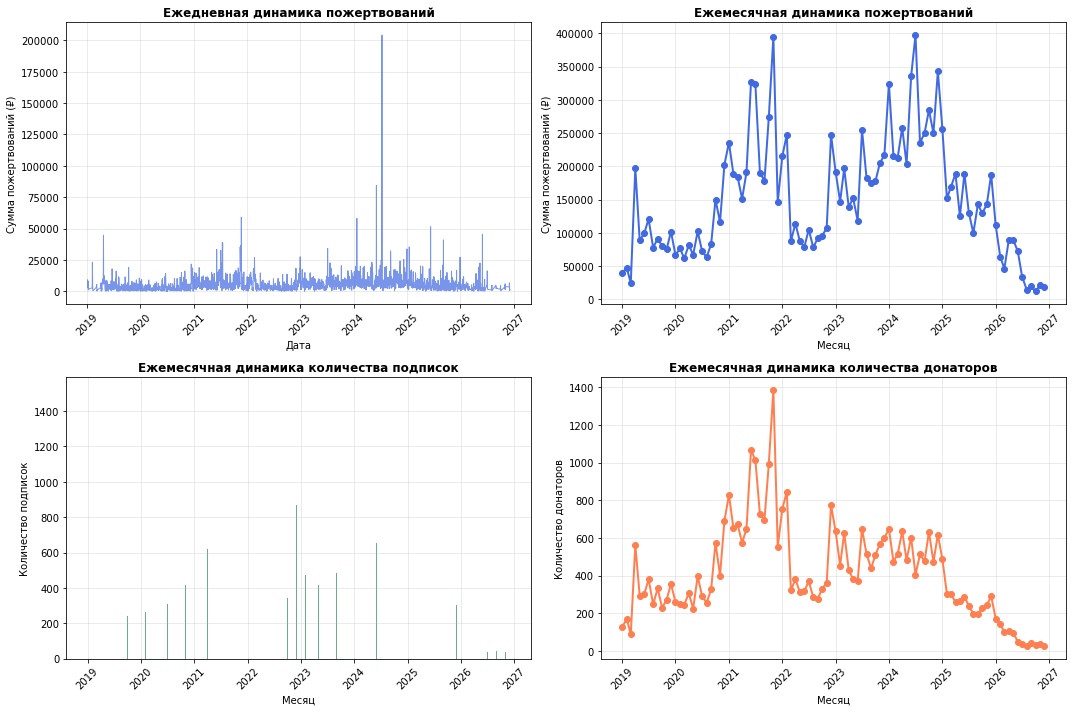

In [20]:
# 3.1 Динамика объема пожертвований
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# График 1: Ежедневная динамика суммы пожертвований
ax1 = axes[0, 0]
ax1.plot(daily_stats['Дата'], daily_stats['Сумма'], color='royalblue', alpha=0.7, linewidth=1)
ax1.set_title('Ежедневная динамика пожертвований', fontsize=12, fontweight='bold')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Сумма пожертвований (₽)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# График 2: Ежемесячная динамика суммы пожертвований
ax2 = axes[0, 1]
ax2.plot(monthly_stats['Дата_месяц'], monthly_stats['Сумма'], marker='o', color='royalblue', linewidth=2)
ax2.set_title('Ежемесячная динамика пожертвований', fontsize=12, fontweight='bold')
ax2.set_xlabel('Месяц')
ax2.set_ylabel('Сумма пожертвований (₽)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# График 3: Ежемесячная динамика количества подписок
ax3 = axes[1, 0]
ax3.bar(monthly_stats['Дата_месяц'], monthly_stats['ID'], color='seagreen', alpha=0.7)
ax3.set_title('Ежемесячная динамика количества подписок', fontsize=12, fontweight='bold')
ax3.set_xlabel('Месяц')
ax3.set_ylabel('Количество подписок')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# График 4: Ежемесячная динамика количества донаторов
ax4 = axes[1, 1]
ax4.plot(monthly_stats['Дата_месяц'], monthly_stats['ID плательщика'], 
         marker='o', color='coral', linewidth=2)
ax4.set_title('Ежемесячная динамика количества донаторов', fontsize=12, fontweight='bold')
ax4.set_xlabel('Месяц')
ax4.set_ylabel('Количество донаторов')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

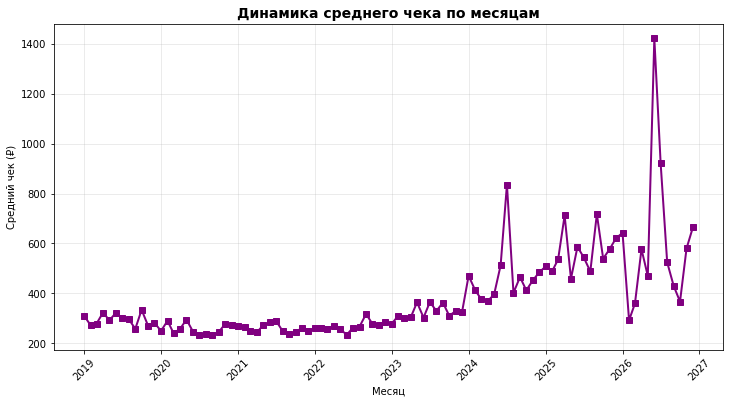

In [21]:
# 3.2 Динамика среднего чека
monthly_avg_check = df.groupby('Год_месяц')['Сумма'].mean().reset_index()
monthly_avg_check['Дата_месяц'] = monthly_avg_check['Год_месяц'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
plt.plot(monthly_avg_check['Дата_месяц'], monthly_avg_check['Сумма'], 
         marker='s', color='purple', linewidth=2)
plt.title('Динамика среднего чека по месяцам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('Средний чек (₽)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()


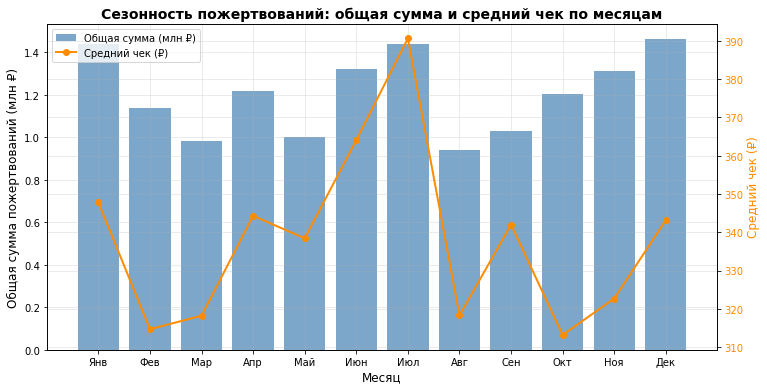

In [22]:
# 3.3 Сезонность и темпы роста

# Добавим колонку для номера месяца и года
df['Месяц_номер'] = df['Дата/время создания'].dt.month
df['Год_номер'] = df['Дата/время создания'].dt.year

# Сезонность: средняя сумма пожертвований по месяцам (без учета года)
seasonal_stats = df.groupby('Месяц_номер').agg({
    'Сумма': ['mean', 'median', 'sum'],
    'ID': 'count'
}).round(2)

seasonal_stats.columns = ['Средняя_сумма', 'Медианная_сумма', 'Общая_сумма', 'Количество_подписок']

# График сезонности
fig, ax = plt.subplots(figsize=(12, 6))
# Используем двойную ось для двух масштабов
ax2 = ax.twinx()

ax.bar(seasonal_stats.index, seasonal_stats['Общая_сумма'] / 1000000, 
       color='steelblue', alpha=0.7, label='Общая сумма (млн ₽)')
ax2.plot(seasonal_stats.index, seasonal_stats['Средняя_сумма'], 
         marker='o', color='darkorange', linewidth=2, label='Средний чек (₽)')

ax.set_xlabel('Месяц', fontsize=12)
ax.set_ylabel('Общая сумма пожертвований (млн ₽)', fontsize=12)
ax2.set_ylabel('Средний чек (₽)', fontsize=12, color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax.set_title('Сезонность пожертвований: общая сумма и средний чек по месяцам', 
             fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
                    'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])

# Добавляем легенду
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax.grid(True, alpha=0.3)
plt.show()


--- Темпы роста за последние 12 месяцев (месяц к месяцу) ---


,Дата_месяц,Рост_суммы_%,Рост_подписок_%,Рост_донаторов_%
84,2026-01-01,-40.75,-42.72,-41.24
85,2026-02-01,-42.20,27.17,-16.96
86,2026-03-01,-28.36,-41.82,-30.28
87,2026-04-01,94.43,21.09,8.08
88,2026-05-01,-0.28,22.58,-10.28
89,2026-06-01,-18.71,-73.16,-48.96
90,2026-07-01,-53.01,-27.45,-24.49
91,2026-08-01,-56.91,-24.32,-29.73
92,2026-09-01,31.65,60.71,65.38
93,2026-10-01,-37.38,-26.67,-27.91


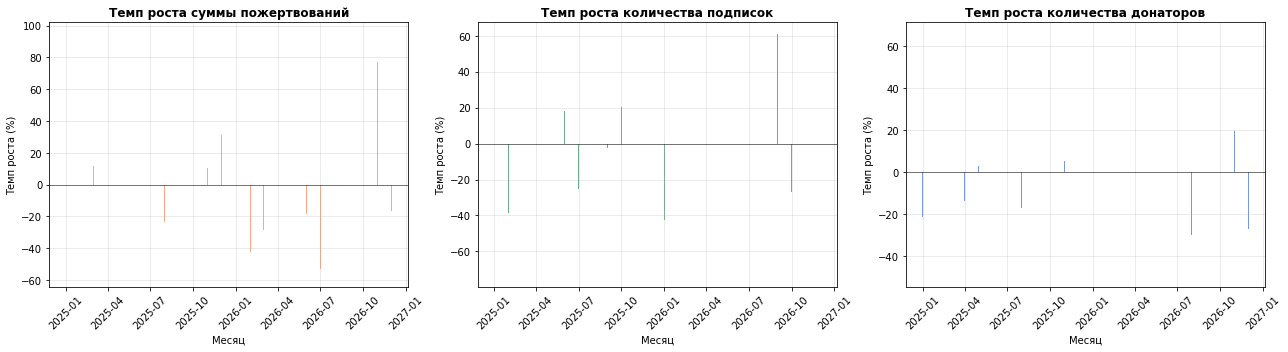

In [23]:
# 3.4 Темпы роста (месяц к месяцу)

# Рассчитываем темпы роста для ключевых показателей
monthly_growth = monthly_stats.copy()
monthly_growth['Рост_суммы_%'] = monthly_growth['Сумма'].pct_change() * 100
monthly_growth['Рост_подписок_%'] = monthly_growth['ID'].pct_change() * 100
monthly_growth['Рост_донаторов_%'] = monthly_growth['ID плательщика'].pct_change() * 100

# Выводим последние 12 месяцев с темпами роста
print("\n--- Темпы роста за последние 12 месяцев (месяц к месяцу) ---")
display(monthly_growth.tail(12)[['Дата_месяц', 'Рост_суммы_%', 'Рост_подписок_%', 'Рост_донаторов_%']].round(2))

# Визуализация темпов роста
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ('Рост_суммы_%', 'Темп роста суммы пожертвований', 'coral'),
    ('Рост_подписок_%', 'Темп роста количества подписок', 'seagreen'),
    ('Рост_донаторов_%', 'Темп роста количества донаторов', 'royalblue')
]

for idx, (col, title, color) in enumerate(metrics):
    ax = axes[idx]
    data = monthly_growth.tail(24)  # последние 24 месяца
    ax.bar(data['Дата_месяц'], data[col], color=color, alpha=0.7)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Месяц')
    ax.set_ylabel('Темп роста (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--- Статистика по годам ---


,Общая_сумма,Средний_чек,Количество_подписок,Количество_донаторов
Год,,,,
2019,1043893.00,297.32,3511,3074
2020,1142320.00,256.70,4450,3832
2021,2782412.00,261.48,10641,8025
2022,1554840.00,268.63,5788,4538
2023,2156605.00,322.99,6677,5190
2024,3309147.78,460.05,7193,5708
2025,1912143.00,558.78,3422,3037
2026,592137.00,526.81,1124,832


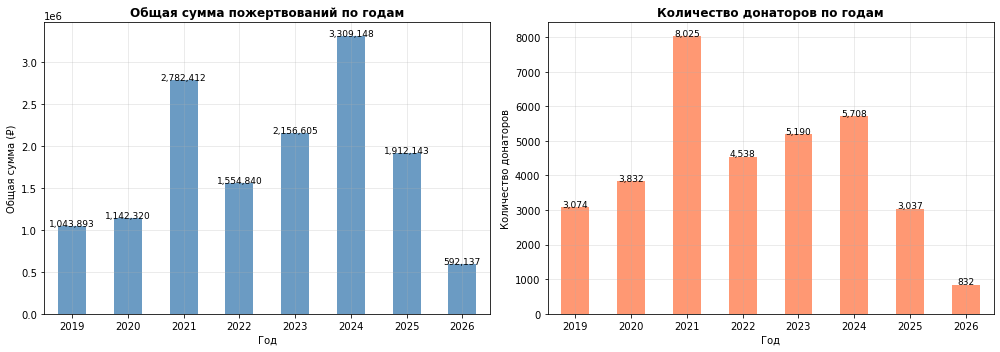

In [24]:
# Дополнительный анализ: распределение сумм по годам

yearly_stats = df.groupby('Год').agg({
    'Сумма': ['sum', 'mean', 'count'],
    'ID плательщика': 'nunique'
}).round(2)

yearly_stats.columns = ['Общая_сумма', 'Средний_чек', 'Количество_подписок', 'Количество_донаторов']

print("\n--- Статистика по годам ---")
display(yearly_stats)

# Визуализация по годам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Сумма пожертвований по годам
ax1 = axes[0]
yearly_stats['Общая_сумма'].plot(kind='bar', ax=ax1, color='steelblue', alpha=0.8)
ax1.set_title('Общая сумма пожертвований по годам', fontsize=12, fontweight='bold')
ax1.set_xlabel('Год')
ax1.set_ylabel('Общая сумма (₽)')
ax1.tick_params(axis='x', rotation=0)
ax1.grid(True, alpha=0.3)
for i, v in enumerate(yearly_stats['Общая_сумма']):
    ax1.text(i, v + 1000, f'{v:,.0f}', ha='center', fontsize=9)

# Количество донаторов по годам
ax2 = axes[1]
yearly_stats['Количество_донаторов'].plot(kind='bar', ax=ax2, color='coral', alpha=0.8)
ax2.set_title('Количество донаторов по годам', fontsize=12, fontweight='bold')
ax2.set_xlabel('Год')
ax2.set_ylabel('Количество донаторов')
ax2.tick_params(axis='x', rotation=0)
ax2.grid(True, alpha=0.3)
for i, v in enumerate(yearly_stats['Количество_донаторов']):
    ax2.text(i, v + 10, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# RFM-анализ и сегментирование донаторов

In [25]:
# Для RFM-анализа нам нужно определить для каждого донатора:
# 1. Recency (Давность) - сколько дней прошло с последнего платежа
# 2. Frequency (Частота) - сколько всего было успешных платежей
# 3. Monetary (Денежная ценность) - общая сумма пожертвований

In [26]:
print("--- Расчет RFM-метрик ---")

--- Расчет RFM-метрик ---


In [27]:
# Определяем дату, относительно которой будем считать давность
# Используем максимальную дату в датасете как "сегодня"
today = df['Дата/время создания'].max()
print(f"Дата анализа (максимальная дата в данных): {today.date()}")

# Создаем датафрейм с RFM-метриками для каждого донатора
rfm_df = df.groupby('ID плательщика').agg({
    'Дата/время создания': 'max',  # последняя дата создания подписки (используем как прокси для последнего действия)
    'ID': 'count',  # количество подписок (Frequency)
    'Сумма': 'sum'  # общая сумма пожертвований (Monetary)
}).reset_index()

# Переименовываем колонки
rfm_df.columns = ['ID плательщика', 'Дата_последнего_действия', 'Frequency', 'Monetary']

# Расчет Recency (количество дней с последнего действия)
rfm_df['Recency'] = (today - rfm_df['Дата_последнего_действия']).dt.days

# Проверяем распределение метрик
print("\n--- Статистика RFM-метрик ---")
print(rfm_df[['Recency', 'Frequency', 'Monetary']].describe())

# --- Создание RFM-сегментов ---

# Функция для присвоения баллов (1-4) на основе квантилей
def rfm_score_r(x):
    if x <= rfm_df['Recency'].quantile(0.25):
        return 4
    elif x <= rfm_df['Recency'].quantile(0.50):
        return 3
    elif x <= rfm_df['Recency'].quantile(0.75):
        return 2
    else:
        return 1

def rfm_score_f(x):
    if x >= rfm_df['Frequency'].quantile(0.75):
        return 4
    elif x >= rfm_df['Frequency'].quantile(0.50):
        return 3
    elif x >= rfm_df['Frequency'].quantile(0.25):
        return 2
    else:
        return 1

def rfm_score_m(x):
    if x >= rfm_df['Monetary'].quantile(0.75):
        return 4
    elif x >= rfm_df['Monetary'].quantile(0.50):
        return 3
    elif x >= rfm_df['Monetary'].quantile(0.25):
        return 2
    else:
        return 1
    
# Применяем функции для расчета RFM-баллов
rfm_df['R_Score'] = rfm_df['Recency'].apply(rfm_score_r)
rfm_df['F_Score'] = rfm_df['Frequency'].apply(rfm_score_f)
rfm_df['M_Score'] = rfm_df['Monetary'].apply(rfm_score_m)

# Создаем составной RFM-сегмент
rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

# Создаем категории на основе RFM-баллов
def rfm_segment(row):
    if row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Супер-донаторы (Champions)'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 2 and row['M_Score'] >= 2:
        return 'Лояльные донаторы (Loyal)'
    elif row['R_Score'] >= 3 and row['F_Score'] <= 2:
        return 'Новые или потенциальные (Potential)'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Ценные, но уходящие (At Risk)'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 2:
        return 'Уходящие донаторы (About to Churn)'
    elif row['R_Score'] <= 1 and row['F_Score'] <= 2:
        return 'Потерянные донаторы (Lost)'
    else:
        return 'Другие (Others)'

rfm_df['Segment'] = rfm_df.apply(rfm_segment, axis=1)
    

Дата анализа (максимальная дата в данных): 2026-12-06

--- Статистика RFM-метрик ---
            Recency     Frequency       Monetary
count  31105.000000  31105.000000   31105.000000
mean    1545.016782      1.376177     465.953955
std      683.608339      2.525305    1595.606819
min        0.000000      1.000000       1.000000
25%      968.000000      1.000000     100.000000
50%     1599.000000      1.000000     200.000000
75%     2049.000000      1.000000     500.000000
max     2892.000000    300.000000  200000.000000



--- Анализ RFM-сегментов ---
                                    Количество_донаторов  Общая_сумма  \
Segment                                                                 
Супер-донаторы (Champions)                         11943   8874918.07   
Ценные, но уходящие (At Risk)                       9911   4722996.00   
Уходящие донаторы (About to Churn)                  5637    546997.00   
Лояльные донаторы (Loyal)                           3248    332540.00   
Другие (Others)                                      366     16046.71   

                                    Средняя_сумма  Медианная_сумма  \
Segment                                                              
Супер-донаторы (Champions)                 743.11            500.0   
Ценные, но уходящие (At Risk)              476.54            300.0   
Уходящие донаторы (About to Churn)          97.04            100.0   
Лояльные донаторы (Loyal)                  102.38            100.0   
Другие (Others)                       

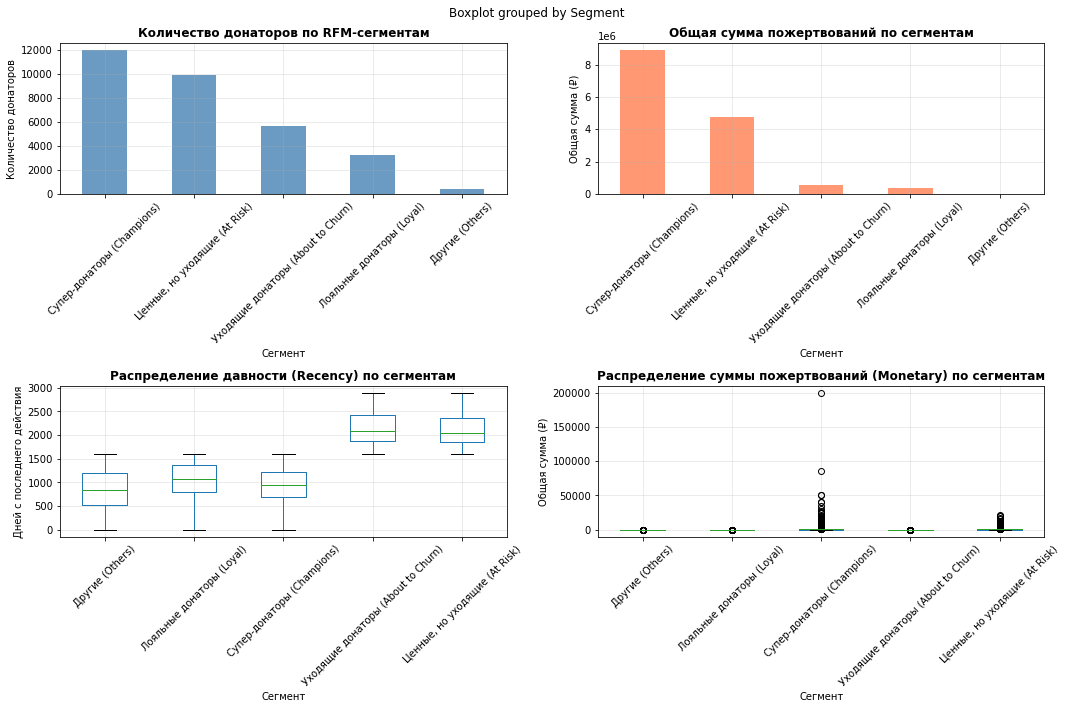

In [28]:
# --- Анализ сегментов ---

print("\n--- Анализ RFM-сегментов ---")
segment_analysis = rfm_df.groupby('Segment').agg({
    'ID плательщика': 'count',
    'Monetary': ['sum', 'mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Recency': ['mean', 'median']
}).round(2)

# Переименовываем колонки для удобства
segment_analysis.columns = ['Количество_донаторов', 'Общая_сумма', 'Средняя_сумма', 'Медианная_сумма',
                           'Средняя_частота', 'Медианная_частота', 'Средняя_давность', 'Медианная_давность']
segment_analysis = segment_analysis.sort_values('Общая_сумма', ascending=False)

print(segment_analysis)

# --- Визуализация RFM-сегментов ---

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Количество донаторов по сегментам
ax1 = axes[0, 0]
segment_counts = rfm_df['Segment'].value_counts()
segment_counts.plot(kind='bar', ax=ax1, color='steelblue', alpha=0.8)
ax1.set_title('Количество донаторов по RFM-сегментам', fontsize=12, fontweight='bold')
ax1.set_xlabel('Сегмент')
ax1.set_ylabel('Количество донаторов')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# 2. Общая сумма пожертвований по сегментам
ax2 = axes[0, 1]
segment_sum = rfm_df.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
segment_sum.plot(kind='bar', ax=ax2, color='coral', alpha=0.8)
ax2.set_title('Общая сумма пожертвований по сегментам', fontsize=12, fontweight='bold')
ax2.set_xlabel('Сегмент')
ax2.set_ylabel('Общая сумма (₽)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# 3. Распределение Recency (давности) по сегментам
ax3 = axes[1, 0]
rfm_df.boxplot(column='Recency', by='Segment', ax=ax3)
ax3.set_title('Распределение давности (Recency) по сегментам', fontsize=12, fontweight='bold')
ax3.set_xlabel('Сегмент')
ax3.set_ylabel('Дней с последнего действия')
ax3.tick_params(axis='x', rotation=45)

# 4. Распределение Monetary по сегментам
ax4 = axes[1, 1]
rfm_df.boxplot(column='Monetary', by='Segment', ax=ax4)
ax4.set_title('Распределение суммы пожертвований (Monetary) по сегментам', fontsize=12, fontweight='bold')
ax4.set_xlabel('Сегмент')
ax4.set_ylabel('Общая сумма (₽)')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

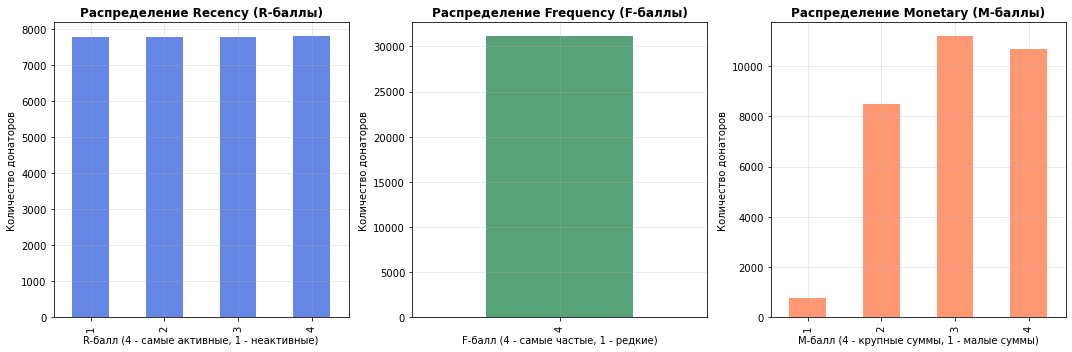

In [29]:
# --- Распределение RFM-баллов ---

# Визуализация распределения RFM-баллов
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Распределение R-баллов
ax1 = axes[0]
r_dist = rfm_df['R_Score'].value_counts().sort_index()
r_dist.plot(kind='bar', ax=ax1, color='royalblue', alpha=0.8)
ax1.set_title('Распределение Recency (R-баллы)', fontsize=12, fontweight='bold')
ax1.set_xlabel('R-балл (4 - самые активные, 1 - неактивные)')
ax1.set_ylabel('Количество донаторов')
ax1.grid(True, alpha=0.3)

# 2. Распределение F-баллов
ax2 = axes[1]
f_dist = rfm_df['F_Score'].value_counts().sort_index()
f_dist.plot(kind='bar', ax=ax2, color='seagreen', alpha=0.8)
ax2.set_title('Распределение Frequency (F-баллы)', fontsize=12, fontweight='bold')
ax2.set_xlabel('F-балл (4 - самые частые, 1 - редкие)')
ax2.set_ylabel('Количество донаторов')
ax2.grid(True, alpha=0.3)

# 3. Распределение M-баллов
ax3 = axes[2]
m_dist = rfm_df['M_Score'].value_counts().sort_index()
m_dist.plot(kind='bar', ax=ax3, color='coral', alpha=0.8)
ax3.set_title('Распределение Monetary (M-баллы)', fontsize=12, fontweight='bold')
ax3.set_xlabel('M-балл (4 - крупные суммы, 1 - малые суммы)')
ax3.set_ylabel('Количество донаторов')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# --- Топ-10 донаторов по RFM-баллу ---
print("\n--- Топ-10 донаторов по общему RFM-баллу ---")
top_rfm = rfm_df.sort_values(['R_Score', 'F_Score', 'M_Score'], ascending=[False, False, False])
display(top_rfm.head(10)[['ID плательщика', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']])

# --- Рекомендации по сегментам ---
print("\n--- Рекомендации по работе с сегментами ---")
recommendations = {
    'Супер-донаторы (Champions)': '🌟 Активировать в программе лояльности, предлагать эксклюзивные возможности, приглашать к участию в мероприятиях',
    'Лояльные донаторы (Loyal)': '🤝 Поддерживать вовлеченность, отправлять персонализированные благодарности, рассказывать о достижениях фонда',
    'Новые или потенциальные (Potential)': '🌱 Информировать о влиянии пожертвований, предлагать регулярные подписки, вовлекать в сообщество',
    'Ценные, но уходящие (At Risk)': '⚡ Срочно коммуницировать, напоминать о ценности, предлагать удобные способы восстановления подписки',
    'Уходящие донаторы (About to Churn)': '📨 Отправлять re-engagement кампании, спрашивать о причинах ухода, предлагать альтернативные форматы участия',
    'Потерянные донаторы (Lost)': '🔄 Минимальные усилия, возможно разовое обращение с обновленной информацией о фонде'
}

for segment, rec in recommendations.items():
    count = segment_counts.get(segment, 0)
    if count > 0:
        print(f"\n{segment} ({count} донаторов):")
        print(f"   {rec}")


--- Топ-10 донаторов по общему RFM-баллу ---


,ID плательщика,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
5,PID_001091d55c32,752,5,1100.0,4,4,4,444,Супер-донаторы (Champions)
9,PID_00162b7ffdcd,920,1,500.0,4,4,4,444,Супер-донаторы (Champions)
11,PID_0018a41c15e1,516,1,1000.0,4,4,4,444,Супер-донаторы (Champions)
13,PID_00193b6aa729,892,2,2000.0,4,4,4,444,Супер-донаторы (Champions)
18,PID_0020fbcdd8c3,828,2,500.0,4,4,4,444,Супер-донаторы (Champions)
23,PID_00272d117f89,483,1,2000.0,4,4,4,444,Супер-донаторы (Champions)
34,PID_004383a6892a,642,1,3000.0,4,4,4,444,Супер-донаторы (Champions)
35,PID_0045d17cfd78,387,2,1500.0,4,4,4,444,Супер-донаторы (Champions)
58,PID_00863aca770a,791,4,4000.0,4,4,4,444,Супер-донаторы (Champions)
60,PID_00875c5c5981,887,1,500.0,4,4,4,444,Супер-донаторы (Champions)



--- Рекомендации по работе с сегментами ---

Супер-донаторы (Champions) (11943 донаторов):
   🌟 Активировать в программе лояльности, предлагать эксклюзивные возможности, приглашать к участию в мероприятиях

Лояльные донаторы (Loyal) (3248 донаторов):
   🤝 Поддерживать вовлеченность, отправлять персонализированные благодарности, рассказывать о достижениях фонда

Ценные, но уходящие (At Risk) (9911 донаторов):
   ⚡ Срочно коммуницировать, напоминать о ценности, предлагать удобные способы восстановления подписки

Уходящие донаторы (About to Churn) (5637 донаторов):
   📨 Отправлять re-engagement кампании, спрашивать о причинах ухода, предлагать альтернативные форматы участия


# Когортный анализ

In [31]:
print("--- Когортный анализ ---")

# Определяем месяц первого пожертвования для каждого донатора
# Для этого находим минимальную дату создания подписки для каждого донатора
first_payment = df.groupby('ID плательщика')['Дата/время создания'].min().reset_index()
first_payment.columns = ['ID плательщика', 'Дата_первого_платежа']

# Создаем колонку с месяцем первого платежа (когорта)
first_payment['Когорта_месяц'] = first_payment['Дата_первого_платежа'].dt.to_period('M')

# Добавляем информацию о когорте к основному датасету
df_with_cohort = df.merge(first_payment[['ID плательщика', 'Когорта_месяц']], on='ID плательщика', how='left')

# Добавляем номер месяца жизни донатора (сколько месяцев прошло с первого платежа)
df_with_cohort['Номер_месяца_жизни'] = (df_with_cohort['Дата/время создания'].dt.year - df_with_cohort['Когорта_месяц'].dt.year) * 12 + \
                                        (df_with_cohort['Дата/время создания'].dt.month - df_with_cohort['Когорта_месяц'].dt.month)

# Создаем когортную таблицу для удержания (Retention)
# Определяем, сколько уникальных донаторов из каждой когорты совершили платеж в каждый месяц жизни

# Группируем по когорте и номеру месяца жизни
cohort_retention = df_with_cohort.groupby(['Когорта_месяц', 'Номер_месяца_жизни']).agg({
    'ID плательщика': 'nunique'  # количество уникальных донаторов
}).reset_index()

# Переименовываем колонку
cohort_retention.columns = ['Когорта_месяц', 'Номер_месяца_жизни', 'Количество_донаторов']

# Создаем сводную таблицу для удержания
retention_pivot = cohort_retention.pivot(index='Когорта_месяц', columns='Номер_месяца_жизни', values='Количество_донаторов')

# Заполняем пропуски нулями
retention_pivot = retention_pivot.fillna(0)

# Преобразуем индексы для удобства
retention_pivot.index = retention_pivot.index.astype(str)

# Сортируем по дате (от старых к новым)
retention_pivot = retention_pivot.sort_index()

# Вычисляем удержание в процентах (относительно первого месяца)
retention_pct = retention_pivot.div(retention_pivot.iloc[:, 0], axis=0) * 100

print("\n--- Матрица удержания (количество донаторов по месяцам жизни) ---")
display(retention_pivot.head(10))

print("\n--- Матрица удержания в процентах ---")
display(retention_pct.head(10).round(1))

--- Когортный анализ ---

--- Матрица удержания (количество донаторов по месяцам жизни) ---


Номер_месяца_жизни,0,1,2,3,4,5,6,7,8,9,...,69,70,71,72,73,75,79,80,84,87
Когорта_месяц,,,,,,,,,,,,,,,,,,,,,
2019-01,126.0,1.0,1.0,5.0,2.0,1.0,4.0,4.0,4.0,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2019-02,168.0,1.0,6.0,3.0,5.0,3.0,6.0,7.0,2.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2019-03,86.0,2.0,1.0,3.0,2.0,1.0,4.0,4.0,3.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-04,549.0,23.0,4.0,5.0,9.0,5.0,3.0,4.0,10.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2019-05,264.0,5.0,6.0,3.0,4.0,4.0,7.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-06,283.0,8.0,2.0,8.0,3.0,3.0,4.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-07,352.0,8.0,7.0,6.0,2.0,5.0,1.0,1.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-08,214.0,5.0,4.0,0.0,0.0,2.0,2.0,3.0,3.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-09,288.0,8.0,6.0,3.0,4.0,2.0,1.0,1.0,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0



--- Матрица удержания в процентах ---


Номер_месяца_жизни,0,1,2,3,4,5,6,7,8,9,...,69,70,71,72,73,75,79,80,84,87
Когорта_месяц,,,,,,,,,,,,,,,,,,,,,
2019-01,100.0,0.8,0.8,4.0,1.6,0.8,3.2,3.2,3.2,1.6,...,0.0,0.0,0.0,0.0,0.8,0.0,0.0,0.0,0.0,0.0
2019-02,100.0,0.6,3.6,1.8,3.0,1.8,3.6,4.2,1.2,1.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.6,0.0,0.0
2019-03,100.0,2.3,1.2,3.5,2.3,1.2,4.7,4.7,3.5,1.2,...,0.0,0.0,0.0,1.2,0.0,0.0,0.0,0.0,0.0,0.0
2019-04,100.0,4.2,0.7,0.9,1.6,0.9,0.5,0.7,1.8,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2
2019-05,100.0,1.9,2.3,1.1,1.5,1.5,2.7,0.8,0.8,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-06,100.0,2.8,0.7,2.8,1.1,1.1,1.4,0.0,0.4,0.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-07,100.0,2.3,2.0,1.7,0.6,1.4,0.3,0.3,0.6,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-08,100.0,2.3,1.9,0.0,0.0,0.9,0.9,1.4,1.4,0.5,...,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-09,100.0,2.8,2.1,1.0,1.4,0.7,0.3,0.3,0.3,0.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.0


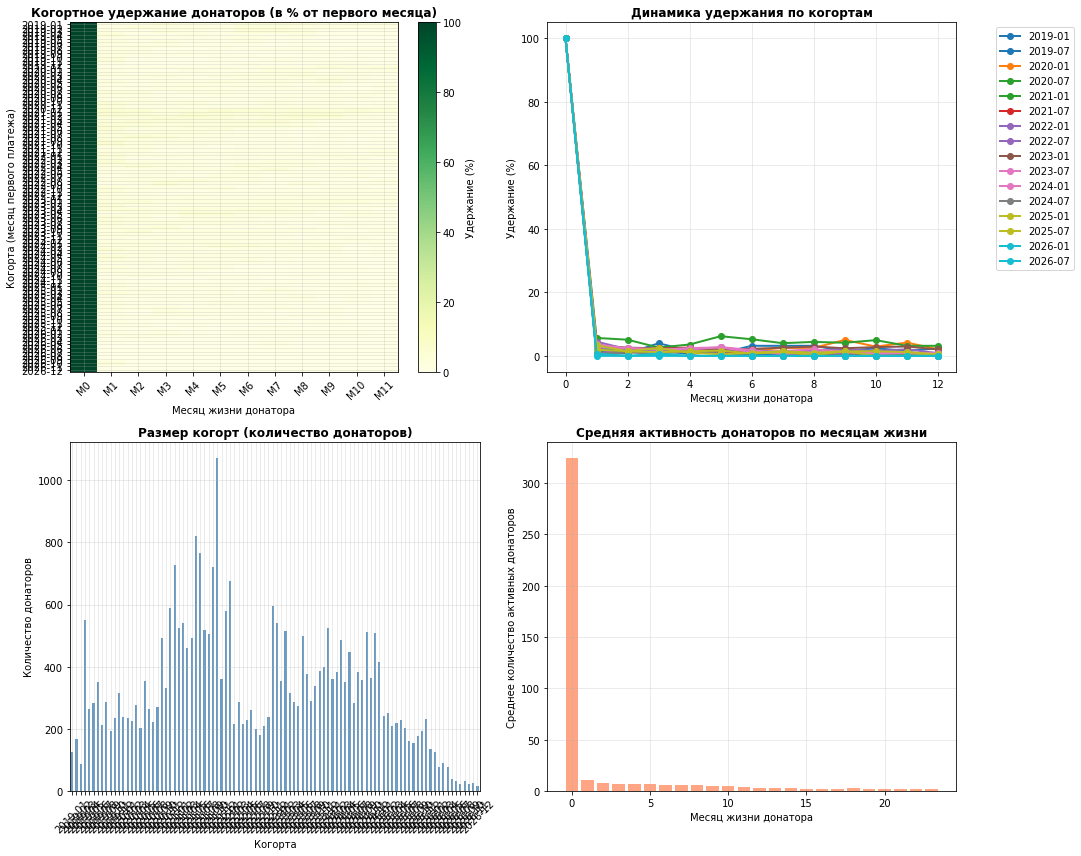

In [32]:
# --- Визуализация когортного анализа ---

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Тепловая карта удержания (в процентах)
ax1 = axes[0, 0]
# Берем только первые 12 месяцев для наглядности
retention_pct_12 = retention_pct.iloc[:, :12]
# Создаем тепловую карту
im = ax1.imshow(retention_pct_12.values, cmap='YlGn', aspect='auto', vmin=0, vmax=100)

# Настройка осей
ax1.set_xticks(range(len(retention_pct_12.columns)))
ax1.set_xticklabels([f'M{int(col)}' for col in retention_pct_12.columns], rotation=45)
ax1.set_yticks(range(len(retention_pct_12.index)))
ax1.set_yticklabels(retention_pct_12.index)

ax1.set_title('Когортное удержание донаторов (в % от первого месяца)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Месяц жизни донатора')
ax1.set_ylabel('Когорта (месяц первого платежа)')

# Добавляем цветовую шкалу
plt.colorbar(im, ax=ax1, label='Удержание (%)')

# 2. Линии удержания для выбранных когорт (каждый 3-й месяц для наглядности)
ax2 = axes[0, 1]
# Выбираем несколько когорт для отображения
cohorts_to_show = retention_pct.index[::6]  # каждую 6-ю когорту
colors = plt.cm.tab10(np.linspace(0, 1, len(cohorts_to_show)))

for i, cohort in enumerate(cohorts_to_show):
    if cohort in retention_pct.index:
        data = retention_pct.loc[cohort, :12]  # первые 12 месяцев
        ax2.plot(data.index, data.values, marker='o', label=cohort, color=colors[i % len(colors)], linewidth=2)

ax2.set_title('Динамика удержания по когортам', fontsize=12, fontweight='bold')
ax2.set_xlabel('Месяц жизни донатора')
ax2.set_ylabel('Удержание (%)')
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
ax2.grid(True, alpha=0.3)

# 3. Размер когорт (количество донаторов в первом месяце)
ax3 = axes[1, 0]
cohort_size = retention_pivot.iloc[:, 0]  # количество донаторов в первом месяце
cohort_size.plot(kind='bar', ax=ax3, color='steelblue', alpha=0.8)
ax3.set_title('Размер когорт (количество донаторов)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Когорта')
ax3.set_ylabel('Количество донаторов')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# 4. Активность донаторов по месяцам жизни (среднее количество платежей)
ax4 = axes[1, 1]
# Расчет среднего количества платежей по месяцам жизни
avg_activity = cohort_retention.groupby('Номер_месяца_жизни')['Количество_донаторов'].mean()
# Берем только первые 24 месяца
avg_activity_24 = avg_activity[:24]
ax4.bar(avg_activity_24.index, avg_activity_24.values, color='coral', alpha=0.7)
ax4.set_title('Средняя активность донаторов по месяцам жизни', fontsize=12, fontweight='bold')
ax4.set_xlabel('Месяц жизни донатора')
ax4.set_ylabel('Среднее количество активных донаторов')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
# --- Анализ жизненного цикла когорт ---

print("\n--- Анализ жизненного цикла когорт ---")

# Рассчитываем продолжительность жизни для каждой когорты
cohort_lifetime = {}

for cohort in retention_pct.index:
    # Находим последний месяц, когда удержание было > 0
    active_months = retention_pct.loc[cohort][retention_pct.loc[cohort] > 0]
    if len(active_months) > 0:
        max_month = active_months.index[-1]
        cohort_lifetime[cohort] = {
            'Максимальный_месяц_жизни': max_month,
            'Количество_активных_месяцев': len(active_months),
            'Удержание_3_мес': retention_pct.loc[cohort][3] if 3 in retention_pct.columns else 0,
            'Удержание_6_мес': retention_pct.loc[cohort][6] if 6 in retention_pct.columns else 0,
            'Удержание_12_мес': retention_pct.loc[cohort][12] if 12 in retention_pct.columns else 0
        }

# Преобразуем в датафрейм
lifetime_df = pd.DataFrame.from_dict(cohort_lifetime, orient='index')
lifetime_df.index.name = 'Когорта'
lifetime_df = lifetime_df.reset_index()

print("\n--- Показатели жизненного цикла по когортам ---")
display(lifetime_df)


--- Анализ жизненного цикла когорт ---

--- Показатели жизненного цикла по когортам ---


,Когорта,Максимальный_месяц_жизни,Количество_активных_месяцев,Удержание_3_мес,Удержание_6_мес,Удержание_12_мес
0,2019-01,73,31,3.968254,3.174603,2.380952
1,2019-02,80,39,1.785714,3.571429,1.190476
2,2019-03,72,32,3.488372,4.651163,1.162791
3,2019-04,87,39,0.910747,0.546448,0.728597
4,2019-05,68,31,1.136364,2.651515,0.378788
...,...,...,...,...,...,...
91,2026-08,0,1,0.000000,0.000000,0.000000
92,2026-09,0,1,0.000000,0.000000,0.000000
93,2026-10,1,2,0.000000,0.000000,0.000000
94,2026-11,0,1,0.000000,0.000000,0.000000


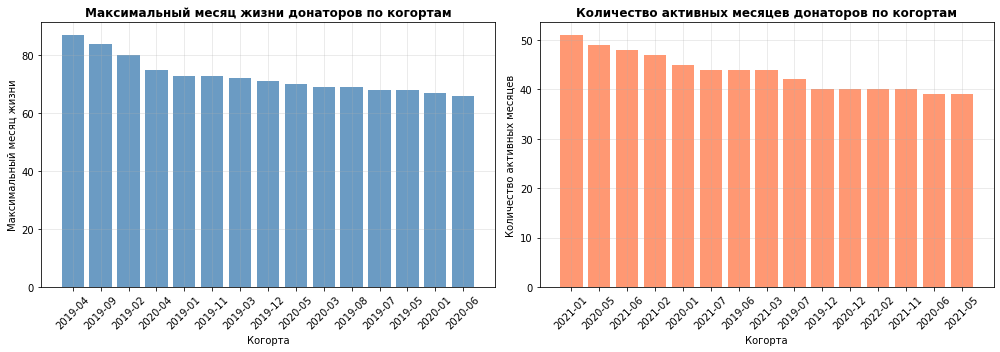

In [34]:
# Визуализация продолжительности жизни когорт
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Максимальный месяц жизни по когортам
ax1 = axes[0]
lifetime_df_sorted = lifetime_df.sort_values('Максимальный_месяц_жизни', ascending=False).head(15)
ax1.bar(lifetime_df_sorted['Когорта'], lifetime_df_sorted['Максимальный_месяц_жизни'], color='steelblue', alpha=0.8)
ax1.set_title('Максимальный месяц жизни донаторов по когортам', fontsize=12, fontweight='bold')
ax1.set_xlabel('Когорта')
ax1.set_ylabel('Максимальный месяц жизни')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# 2. Количество активных месяцев по когортам
ax2 = axes[1]
lifetime_df_sorted = lifetime_df.sort_values('Количество_активных_месяцев', ascending=False).head(15)
ax2.bar(lifetime_df_sorted['Когорта'], lifetime_df_sorted['Количество_активных_месяцев'], color='coral', alpha=0.8)
ax2.set_title('Количество активных месяцев донаторов по когортам', fontsize=12, fontweight='bold')
ax2.set_xlabel('Когорта')
ax2.set_ylabel('Количество активных месяцев')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--- Среднее удержание по месяцам жизни (в среднем по всем когортам) ---
Номер_месяца_жизни
0     100.0
1       2.5
2       1.8
3       1.5
4       1.5
5       1.4
6       1.4
7       1.4
8       1.2
9       1.0
10      0.8
11      0.7
12      0.6
13      0.7
14      0.5
15      0.4
16      0.4
17      0.5
18      0.4
19      0.4
20      0.3
21      0.3
22      0.2
23      0.3
dtype: float64


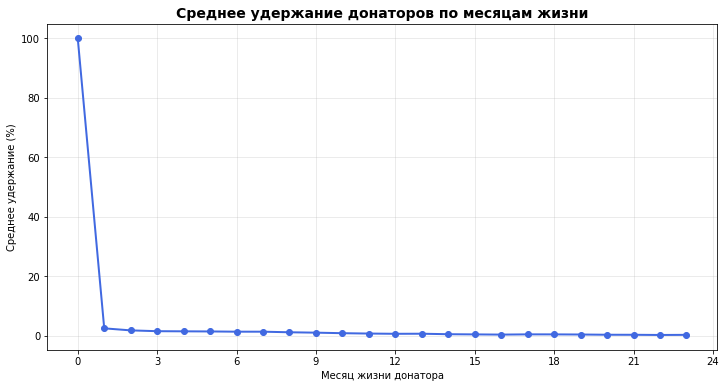

In [35]:
# --- Среднее удержание по месяцам ---

print("\n--- Среднее удержание по месяцам жизни (в среднем по всем когортам) ---")
avg_retention_by_month = retention_pct.mean(axis=0)

# Берем первые 24 месяца
avg_retention_24 = avg_retention_by_month[:24]
print(avg_retention_24.round(1))

# Визуализация среднего удержания
plt.figure(figsize=(12, 6))
plt.plot(avg_retention_24.index, avg_retention_24.values, marker='o', color='royalblue', linewidth=2)
plt.title('Среднее удержание донаторов по месяцам жизни', fontsize=14, fontweight='bold')
plt.xlabel('Месяц жизни донатора')
plt.ylabel('Среднее удержание (%)')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 25, 3))
plt.show()


In [36]:
# --- Выводы по когортному анализу ---

print("\n--- Ключевые выводы по когортному анализу ---")

# Вычисляем среднее удержание на ключевых точках
retention_1 = avg_retention_24[1] if 1 in avg_retention_24.index else 0
retention_3 = avg_retention_24[3] if 3 in avg_retention_24.index else 0
retention_6 = avg_retention_24[6] if 6 in avg_retention_24.index else 0
retention_12 = avg_retention_24[12] if 12 in avg_retention_24.index else 0

print(f"Среднее удержание через 1 месяц: {retention_1:.1f}%")
print(f"Среднее удержание через 3 месяца: {retention_3:.1f}%")
print(f"Среднее удержание через 6 месяцев: {retention_6:.1f}%")
print(f"Среднее удержание через 12 месяцев: {retention_12:.1f}%")

# Анализ жизненного цикла
if len(lifetime_df) > 0:
    avg_lifetime = lifetime_df['Количество_активных_месяцев'].mean()
    max_lifetime = lifetime_df['Количество_активных_месяцев'].max()
    print(f"\nСредняя продолжительность жизни донатора: {avg_lifetime:.1f} месяцев")
    print(f"Максимальная продолжительность жизни донатора: {max_lifetime:.1f} месяцев")


--- Ключевые выводы по когортному анализу ---
Среднее удержание через 1 месяц: 2.5%
Среднее удержание через 3 месяца: 1.5%
Среднее удержание через 6 месяцев: 1.4%
Среднее удержание через 12 месяцев: 0.6%

Средняя продолжительность жизни донатора: 24.4 месяцев
Максимальная продолжительность жизни донатора: 51.0 месяцев


--- Исследование подписок ---
Всего подписок: 42806
Активные подписки (включая просроченные): 6470 (15.1%)
Отмененные подписки: 19259 (45.0%)
Отклоненные подписки: 17025 (39.8%)
В ожидании: 52 (0.1%)


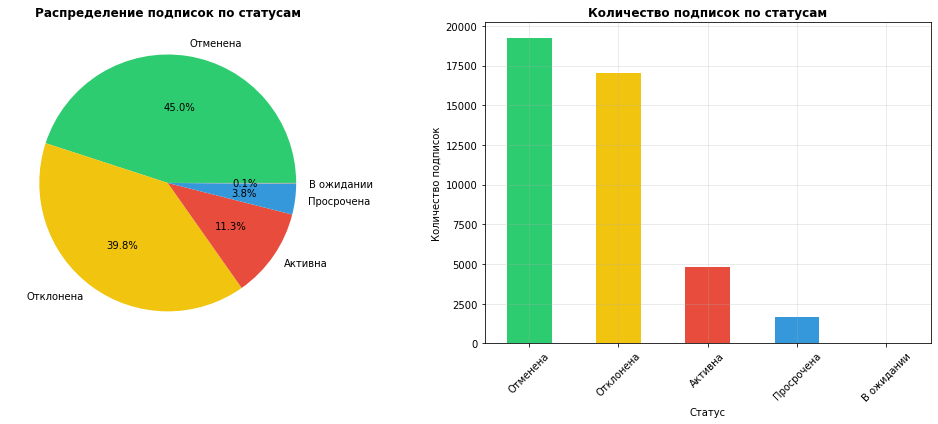

In [37]:
# --- Задача 6: Исследование подписок ---

print("--- Исследование подписок ---")

# 1. Доля регулярных пожертвований
# В нашем датасете все подписки - регулярные (периодичность = "Раз в месяц")
# Но мы можем посчитать, сколько подписок активны в данный момент

total_subscriptions = len(df)
active_subscriptions = df[df['Статус'].isin(['Активна', 'Просрочена'])].shape[0]
completed_subscriptions = df[df['Статус'] == 'Отменена'].shape[0]
rejected_subscriptions = df[df['Статус'] == 'Отклонена'].shape[0]
pending_subscriptions = df[df['Статус'] == 'В ожидании'].shape[0]

print(f"Всего подписок: {total_subscriptions}")
print(f"Активные подписки (включая просроченные): {active_subscriptions} ({active_subscriptions/total_subscriptions*100:.1f}%)")
print(f"Отмененные подписки: {completed_subscriptions} ({completed_subscriptions/total_subscriptions*100:.1f}%)")
print(f"Отклоненные подписки: {rejected_subscriptions} ({rejected_subscriptions/total_subscriptions*100:.1f}%)")
print(f"В ожидании: {pending_subscriptions} ({pending_subscriptions/total_subscriptions*100:.1f}%)")

# Визуализация распределения статусов
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Круговая диаграмма статусов
ax1 = axes[0]
status_counts = df['Статус'].value_counts()
colors = ['#2ecc71', '#f1c40f', '#e74c3c', '#3498db', '#95a5a6']
ax1.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', colors=colors[:len(status_counts)])
ax1.set_title('Распределение подписок по статусам', fontsize=12, fontweight='bold')

# 2. Количество подписок по статусам
ax2 = axes[1]
status_counts.plot(kind='bar', ax=ax2, color=['#2ecc71', '#f1c40f', '#e74c3c', '#3498db', '#95a5a6'])
ax2.set_title('Количество подписок по статусам', fontsize=12, fontweight='bold')
ax2.set_xlabel('Статус')
ax2.set_ylabel('Количество подписок')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--- Анализ длительности подписок ---
Средняя длительность подписки (все): 182.5 дней
Медианная длительность подписки (все): 30.0 дней

Средняя длительность завершенных подписок: 107.3 дней
Медианная длительность завершенных подписок: 4.0 дней


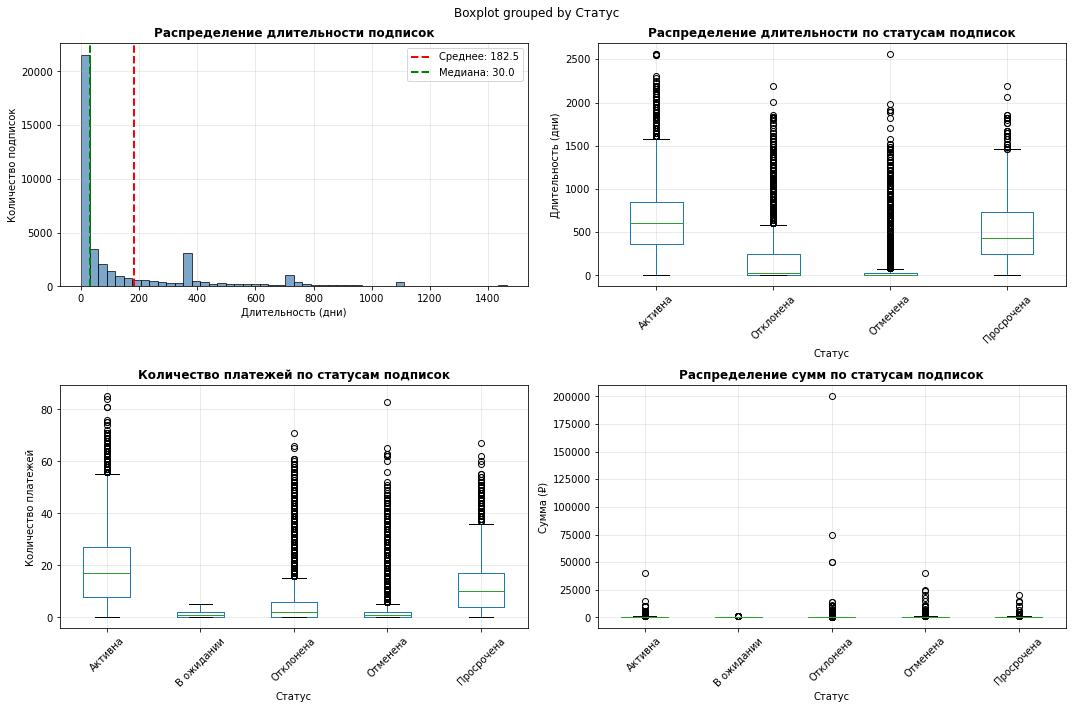

In [38]:
# 2. Средняя длительность подписки
# Для расчета длительности подписки используем разницу между датой создания и датой последнего платежа
# Для активных подписок используем текущую дату

# Создаем копию данных с длительностью подписки
subscription_duration = df.copy()

# Для подписок, у которых есть дата последнего платежа, используем ее
# Для остальных (активных) используем дату создания (длительность = 0)
subscription_duration['Дата_окончания'] = subscription_duration['Дата/время последнего платежа'].fillna(subscription_duration['Дата/время создания'])

# Рассчитываем длительность в днях
subscription_duration['Длительность_дней'] = (subscription_duration['Дата_окончания'] - subscription_duration['Дата/время создания']).dt.days

# Для подписок с нулевой длительностью заменяем на 1 день (минимальная длительность)
subscription_duration['Длительность_дней'] = subscription_duration['Длительность_дней'].clip(lower=1)

# Фильтруем только завершенные подписки для анализа длительности
completed_subscriptions_data = subscription_duration[subscription_duration['Статус'].isin(['Отменена', 'Отклонена'])]

print(f"\n--- Анализ длительности подписок ---")
print(f"Средняя длительность подписки (все): {subscription_duration['Длительность_дней'].mean():.1f} дней")
print(f"Медианная длительность подписки (все): {subscription_duration['Длительность_дней'].median():.1f} дней")

if len(completed_subscriptions_data) > 0:
    print(f"\nСредняя длительность завершенных подписок: {completed_subscriptions_data['Длительность_дней'].mean():.1f} дней")
    print(f"Медианная длительность завершенных подписок: {completed_subscriptions_data['Длительность_дней'].median():.1f} дней")

# 3. Распределение срока жизни подписок
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Гистограмма длительности подписок
ax1 = axes[0, 0]
duration_days = subscription_duration['Длительность_дней']
# Ограничиваем для наглядности (99-й перцентиль)
max_days = duration_days.quantile(0.99)
filtered_duration = duration_days[duration_days <= max_days]
ax1.hist(filtered_duration, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_title('Распределение длительности подписок', fontsize=12, fontweight='bold')
ax1.set_xlabel('Длительность (дни)')
ax1.set_ylabel('Количество подписок')
ax1.grid(True, alpha=0.3)
ax1.axvline(duration_days.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {duration_days.mean():.1f}')
ax1.axvline(duration_days.median(), color='green', linestyle='--', linewidth=2, label=f'Медиана: {duration_days.median():.1f}')
ax1.legend()

# Распределение длительности по статусам (boxplot)
ax2 = axes[0, 1]
statuses_with_duration = subscription_duration[subscription_duration['Статус'].isin(['Активна', 'Отменена', 'Отклонена', 'Просрочена'])]
statuses_with_duration.boxplot(column='Длительность_дней', by='Статус', ax=ax2)
ax2.set_title('Распределение длительности по статусам подписок', fontsize=12, fontweight='bold')
ax2.set_xlabel('Статус')
ax2.set_ylabel('Длительность (дни)')
ax2.tick_params(axis='x', rotation=45)

# Количество платежей по статусам
ax3 = axes[1, 0]
df.boxplot(column='Кол-во платежей', by='Статус', ax=ax3)
ax3.set_title('Количество платежей по статусам подписок', fontsize=12, fontweight='bold')
ax3.set_xlabel('Статус')
ax3.set_ylabel('Количество платежей')
ax3.tick_params(axis='x', rotation=45)

# Распределение сумм по статусам
ax4 = axes[1, 1]
df.boxplot(column='Сумма', by='Статус', ax=ax4)
ax4.set_title('Распределение сумм по статусам подписок', fontsize=12, fontweight='bold')
ax4.set_xlabel('Статус')
ax4.set_ylabel('Сумма (₽)')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



--- Уровень оттока ---
Количество отмененных/отклоненных подписок: 36284
Уровень оттока: 84.8%

--- Уровень оттока по месяцам ---


,Год_месяц,ID,Статус,Уровень_оттока_%
84,2026-01,173,44,25.433526
85,2026-02,220,75,34.090909
86,2026-03,128,36,28.125000
87,2026-04,155,18,11.612903
88,2026-05,190,20,10.526316
89,2026-06,51,6,11.764706
90,2026-07,37,9,24.324324
91,2026-08,28,2,7.142857
92,2026-09,45,8,17.777778
93,2026-10,33,10,30.303030


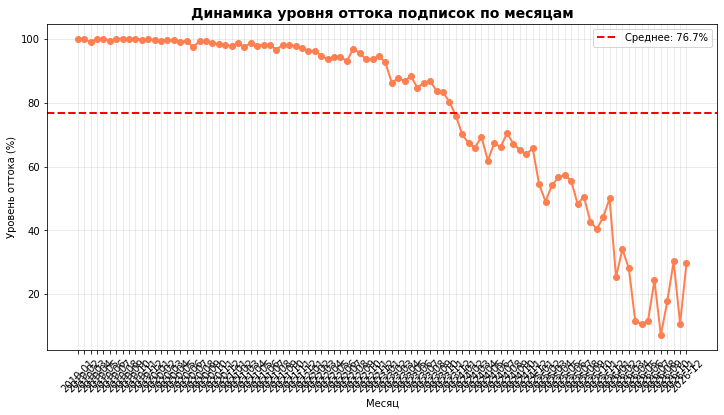

In [39]:
# 4. Уровень оттока (Churn Rate)
# Рассчитываем отток как долю подписок, которые были отменены или отклонены

churned_subscriptions = df[df['Статус'].isin(['Отменена', 'Отклонена'])].shape[0]
churn_rate = churned_subscriptions / total_subscriptions * 100

print(f"\n--- Уровень оттока ---")
print(f"Количество отмененных/отклоненных подписок: {churned_subscriptions}")
print(f"Уровень оттока: {churn_rate:.1f}%")

# Рассчитываем отток по месяцам
monthly_churn = df.groupby('Год_месяц').agg({
    'ID': 'count',
    'Статус': lambda x: (x.isin(['Отменена', 'Отклонена'])).sum()
}).reset_index()
monthly_churn['Уровень_оттока_%'] = monthly_churn['Статус'] / monthly_churn['ID'] * 100

print("\n--- Уровень оттока по месяцам ---")
display(monthly_churn.tail(12))

# Визуализация оттока
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_churn['Год_месяц'].astype(str), monthly_churn['Уровень_оттока_%'], 
        marker='o', color='coral', linewidth=2)
ax.set_title('Динамика уровня оттока подписок по месяцам', fontsize=14, fontweight='bold')
ax.set_xlabel('Месяц')
ax.set_ylabel('Уровень оттока (%)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
ax.axhline(y=monthly_churn['Уровень_оттока_%'].mean(), color='red', linestyle='--', 
           label=f'Среднее: {monthly_churn["Уровень_оттока_%"].mean():.1f}%')
ax.legend()
plt.show()


--- Статистика по донаторам ---
Всего донаторов: 31105
Среднее количество подписок на донатора: 1.38
Среднее количество платежей на донатора: 7.66
Медианное количество платежей на донатора: 2.00


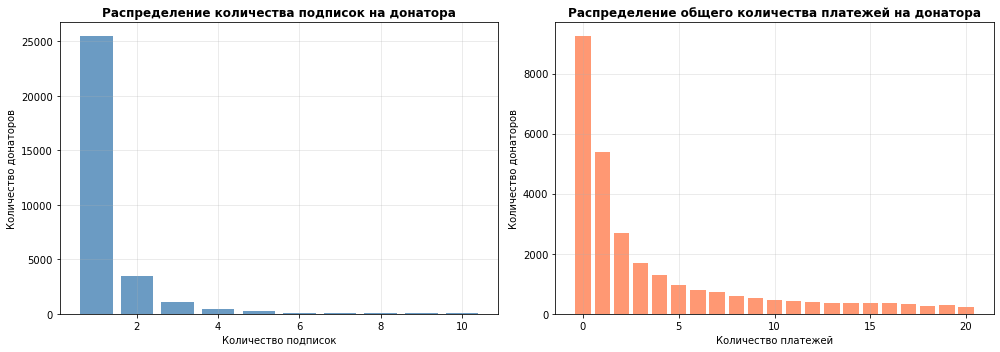

In [40]:
# 5. Среднее количество платежей на подписчика
# Группируем по плательщику и считаем статистику

payer_stats = df.groupby('ID плательщика').agg({
    'ID': 'count',  # количество подписок
    'Сумма': ['sum', 'mean', 'median'],
    'Кол-во платежей': 'sum'  # суммарное количество платежей по всем подпискам
}).reset_index()

payer_stats.columns = ['ID плательщика', 'Количество_подписок', 'Общая_сумма', 'Средняя_сумма', 'Медианная_сумма', 'Всего_платежей']

print(f"\n--- Статистика по донаторам ---")
print(f"Всего донаторов: {len(payer_stats)}")
print(f"Среднее количество подписок на донатора: {payer_stats['Количество_подписок'].mean():.2f}")
print(f"Среднее количество платежей на донатора: {payer_stats['Всего_платежей'].mean():.2f}")
print(f"Медианное количество платежей на донатора: {payer_stats['Всего_платежей'].median():.2f}")

# Распределение количества подписок на донатора
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Распределение количества подписок на донатора
ax1 = axes[0]
subscription_dist = payer_stats['Количество_подписок'].value_counts().sort_index()
subscription_dist = subscription_dist[subscription_dist.index <= 10]  # ограничиваем для наглядности
ax1.bar(subscription_dist.index, subscription_dist.values, color='steelblue', alpha=0.8)
ax1.set_title('Распределение количества подписок на донатора', fontsize=12, fontweight='bold')
ax1.set_xlabel('Количество подписок')
ax1.set_ylabel('Количество донаторов')
ax1.grid(True, alpha=0.3)

# 2. Распределение общего количества платежей на донатора
ax2 = axes[1]
payment_dist = payer_stats['Всего_платежей'].value_counts().sort_index()
payment_dist = payment_dist[payment_dist.index <= 20]  # ограничиваем для наглядности
ax2.bar(payment_dist.index, payment_dist.values, color='coral', alpha=0.8)
ax2.set_title('Распределение общего количества платежей на донатора', fontsize=12, fontweight='bold')
ax2.set_xlabel('Количество платежей')
ax2.set_ylabel('Количество донаторов')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



--- Распределение по длительности подписки (в месяцах) ---


,Количество,Процент
<1 мес,21544,50.329393
1-3 мес,6139,14.341447
3-6 мес,2904,6.784096
6-12 мес,4591,10.725132
1-2 года,4610,10.769518
2-3 года,1956,4.569453
3-4 года,618,1.443723
4-5 лет,329,0.768584
>5 лет,115,0.268654


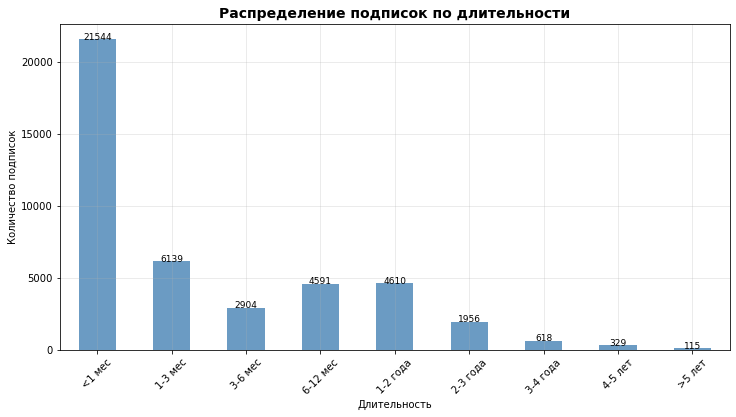


--- Ключевые выводы по исследованию подписок ---
1. Доля активных подписок: 15.1%
2. Средняя длительность подписки: 182.5 дней (6.0 мес)
3. Медианная длительность подписки: 30.0 дней (1.0 мес)
4. Уровень оттока: 84.8%
5. Среднее количество платежей на донатора: 7.66


In [41]:
# 6. Дополнительный анализ: время жизни подписки по месяцам
subscription_duration['Длительность_месяцев'] = subscription_duration['Длительность_дней'] / 30.44  # среднее число дней в месяце

print("\n--- Распределение по длительности подписки (в месяцах) ---")
duration_bins = [0, 1, 3, 6, 12, 24, 36, 48, 60, float('inf')]
duration_labels = ['<1 мес', '1-3 мес', '3-6 мес', '6-12 мес', '1-2 года', '2-3 года', '3-4 года', '4-5 лет', '>5 лет']
subscription_duration['Длительность_категория'] = pd.cut(subscription_duration['Длительность_месяцев'], 
                                                          bins=duration_bins, labels=duration_labels, right=False)

duration_distribution = subscription_duration['Длительность_категория'].value_counts().sort_index()
duration_distribution_pct = duration_distribution / duration_distribution.sum() * 100

duration_df = pd.DataFrame({
    'Количество': duration_distribution,
    'Процент': duration_distribution_pct
})
display(duration_df)

# Визуализация распределения длительности
plt.figure(figsize=(12, 6))
duration_distribution.plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Распределение подписок по длительности', fontsize=14, fontweight='bold')
plt.xlabel('Длительность')
plt.ylabel('Количество подписок')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Добавляем значения на график
for i, v in enumerate(duration_distribution.values):
    plt.text(i, v + 5, f'{v}', ha='center', fontsize=9)

plt.show()

print("\n--- Ключевые выводы по исследованию подписок ---")
print(f"1. Доля активных подписок: {active_subscriptions/total_subscriptions*100:.1f}%")
print(f"2. Средняя длительность подписки: {subscription_duration['Длительность_дней'].mean():.1f} дней ({subscription_duration['Длительность_дней'].mean()/30.44:.1f} мес)")
print(f"3. Медианная длительность подписки: {subscription_duration['Длительность_дней'].median():.1f} дней ({subscription_duration['Длительность_дней'].median()/30.44:.1f} мес)")
print(f"4. Уровень оттока: {churn_rate:.1f}%")
print(f"5. Среднее количество платежей на донатора: {payer_stats['Всего_платежей'].mean():.2f}")

--- Survival Analysis (анализ выживаемости подписок) ---
Всего подписок в анализе: 42806
Завершенных подписок (событий): 36284
Активных подписок (цензурированных): 6522


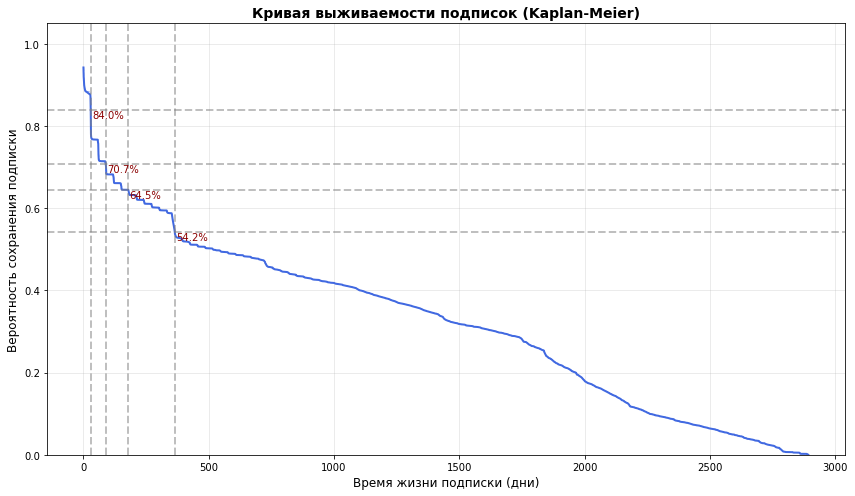

In [42]:
# --- Задача 7: Survival Analysis (анализ выживаемости подписок) ---
# Реализация без использования библиотеки lifelines

print("--- Survival Analysis (анализ выживаемости подписок) ---")

# Для анализа выживаемости нам нужно определить:
# 1. Время жизни подписки (в днях)
# 2. Событие (была ли подписка завершена или все еще активна)

# Подготавливаем данные для анализа выживаемости
survival_data = df.copy()

# Определяем время жизни подписки
# Для завершенных подписок (Отменена, Отклонена) - используем дату последнего платежа
# Для активных подписок - используем текущую дату (цензурирование)

# Создаем колонку с датой окончания подписки
survival_data['Дата_окончания'] = survival_data['Дата/время последнего платежа']

# Для подписок без даты последнего платежа (активные) используем максимальную дату в данных
today = survival_data['Дата/время создания'].max()
survival_data['Дата_окончания'] = survival_data['Дата_окончания'].fillna(today)

# Рассчитываем время жизни в днях
survival_data['Время_жизни_дней'] = (survival_data['Дата_окончания'] - survival_data['Дата/время создания']).dt.days

# Для подписок с нулевой длительностью устанавливаем минимальное значение 1 день
survival_data['Время_жизни_дней'] = survival_data['Время_жизни_дней'].clip(lower=1)

# Создаем колонку события (1 - подписка завершена, 0 - активна/цензурирована)
# Считаем, что подписка завершена, если она имеет статус 'Отменена' или 'Отклонена'
survival_data['Событие'] = survival_data['Статус'].isin(['Отменена', 'Отклонена']).astype(int)

print(f"Всего подписок в анализе: {len(survival_data)}")
print(f"Завершенных подписок (событий): {survival_data['Событие'].sum()}")
print(f"Активных подписок (цензурированных): {len(survival_data) - survival_data['Событие'].sum()}")

# --- 7.1 Расчет кривой Каплана-Майера вручную ---

def kaplan_meier_estimator(times, events):
    """
    Расчет кривой Каплана-Майера вручную
    
    Parameters:
    times (array): время жизни
    events (array): индикатор события (1 - произошло событие, 0 - цензурировано)
    
    Returns:
    tuple: (уникальные времена, вероятность выживания)
    """
    # Сортируем данные по времени
    sorted_indices = np.argsort(times)
    times_sorted = times.iloc[sorted_indices].values
    events_sorted = events.iloc[sorted_indices].values
    
    # Получаем уникальные времена
    unique_times = np.unique(times_sorted)
    
    # Рассчитываем вероятность выживания для каждого уникального времени
    survival_prob = []
    n_risk = len(times_sorted)
    
    for t in unique_times:
        # Количество событий в момент времени t
        n_events = np.sum((times_sorted == t) & (events_sorted == 1))
        # Количество цензурированных в момент времени t
        n_censored = np.sum((times_sorted == t) & (events_sorted == 0))
        
        # Вероятность выживания на шаге t
        if n_risk > 0:
            survival_prob_current = 1 - n_events / n_risk
        else:
            survival_prob_current = 1
        
        # Обновляем количество риска для следующего шага
        n_risk = n_risk - n_events - n_censored
        
        survival_prob.append(survival_prob_current)
    
    # Кумулятивная вероятность выживания
    cumulative_survival = np.cumprod(survival_prob)
    
    return unique_times, cumulative_survival

# Применяем функцию для расчета кривой Каплана-Майера
unique_times, survival_prob = kaplan_meier_estimator(
    survival_data['Время_жизни_дней'], 
    survival_data['Событие']
)

# Создаем датафрейм с результатами
km_results = pd.DataFrame({
    'Время_жизни_дней': unique_times,
    'Вероятность_выживания': survival_prob
})

# --- 7.2 Визуализация кривой Каплана-Майера ---

fig, ax = plt.subplots(figsize=(12, 7))

# Основная кривая
ax.plot(km_results['Время_жизни_дней'], km_results['Вероятность_выживания'], 
        color='royalblue', linewidth=2)

# Добавляем шаговую функцию для наглядности (обычно кривая КМ - ступенчатая)
ax.step(km_results['Время_жизни_дней'], km_results['Вероятность_выживания'], 
        where='post', color='royalblue', alpha=0.5, linestyle='--', linewidth=1)

ax.set_title('Кривая выживаемости подписок (Kaplan-Meier)', fontsize=14, fontweight='bold')
ax.set_xlabel('Время жизни подписки (дни)', fontsize=12)
ax.set_ylabel('Вероятность сохранения подписки', fontsize=12)
ax.grid(True, alpha=0.3)

# Добавляем вертикальные линии для ключевых точек
key_months = [30, 90, 180, 365]  # 1, 3, 6, 12 месяцев
for month in key_months:
    # Находим значение выживаемости в этой точке
    survival_at_month = km_results[km_results['Время_жизни_дней'] <= month]['Вероятность_выживания'].iloc[-1]
    ax.axvline(x=month, color='gray', linestyle='--', alpha=0.5)
    ax.axhline(y=survival_at_month, color='gray', linestyle='--', alpha=0.5)
    ax.text(month + 5, survival_at_month - 0.02, f'{survival_at_month*100:.1f}%', 
            fontsize=10, color='darkred')

# Добавляем подписи для ключевых точек
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [43]:
# --- 7.3 Вероятность сохранения подписки через 1, 3, 6, 12 месяцев ---

print("\n--- Вероятность сохранения подписки ---")
survival_probabilities = {}

for months in [1, 3, 6, 12]:
    days = months * 30.44  # среднее число дней в месяце
    if days <= km_results['Время_жизни_дней'].max():
        survival_prob = km_results[km_results['Время_жизни_дней'] <= days]['Вероятность_выживания'].iloc[-1]
        survival_probabilities[f'{months} месяц(ев)'] = survival_prob
    else:
        survival_prob = km_results['Вероятность_выживания'].iloc[-1]
        survival_probabilities[f'{months} месяц(ев)'] = survival_prob

for period, prob in survival_probabilities.items():
    print(f"Вероятность сохранения подписки через {period}: {prob*100:.1f}%")


--- Вероятность сохранения подписки ---
Вероятность сохранения подписки через 1 месяц(ев): 84.0%
Вероятность сохранения подписки через 3 месяц(ев): 70.1%
Вероятность сохранения подписки через 6 месяц(ев): 63.9%
Вероятность сохранения подписки через 12 месяц(ев): 54.2%



--- Критические периоды ухода донаторов ---

Топ-5 критических дней по количеству отказов (первые 365 дней):
  День 1: 2452.0 отказов в среднем (за 7 дней)
  День 2: 1713.0 отказов в среднем (за 7 дней)
  День 3: 1314.3 отказов в среднем (за 7 дней)
  День 4: 1073.2 отказов в среднем (за 7 дней)
  День 5: 899.6 отказов в среднем (за 7 дней)


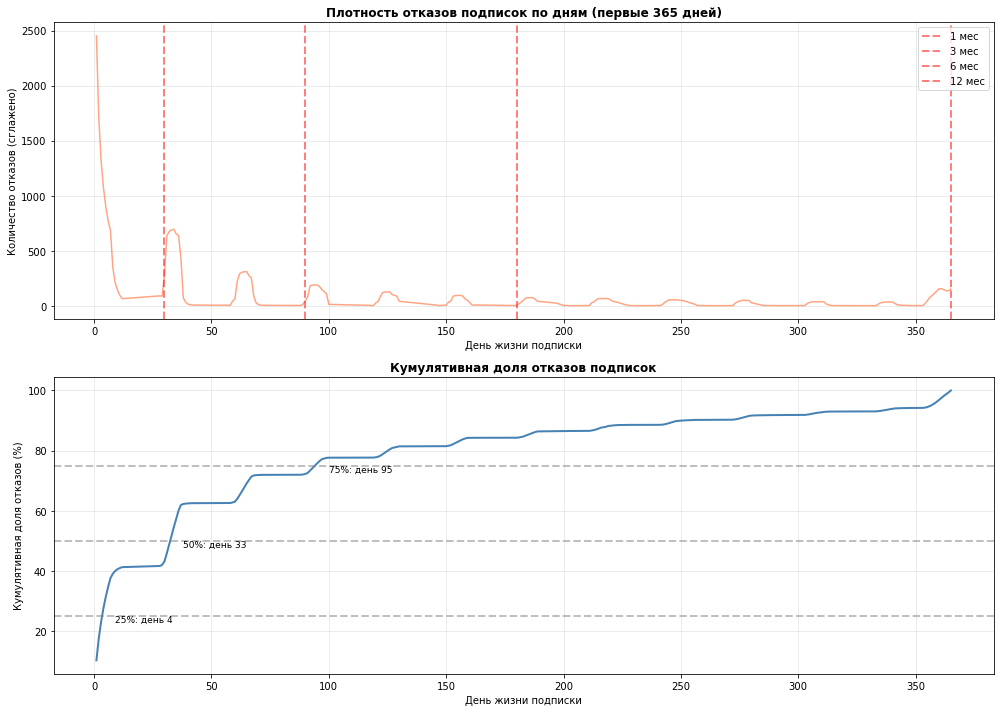

In [44]:
# --- 7.4 Определение наиболее критичных периодов ухода донаторов ---

print("\n--- Критические периоды ухода донаторов ---")

# Рассчитываем плотность событий (отказов) по времени
# Группируем по дням и считаем количество событий
daily_events = survival_data[survival_data['Событие'] == 1].groupby('Время_жизни_дней').size()

# Рассчитываем скользящее среднее для сглаживания
window_size = 7  # 7-дневное окно
daily_events_smoothed = daily_events.rolling(window=window_size, min_periods=1).mean()

# Находим пики оттока (периоды с наибольшим количеством событий)
# Ограничиваемся первыми 365 днями для наглядности
daily_events_365 = daily_events_smoothed[daily_events_smoothed.index <= 365]

if len(daily_events_365) > 0:
    # Находим топ-5 критических дней
    top_critical_days = daily_events_365.nlargest(5)
    print("\nТоп-5 критических дней по количеству отказов (первые 365 дней):")
    for day, events in top_critical_days.items():
        print(f"  День {day}: {events:.1f} отказов в среднем (за {window_size} дней)")

# Визуализация плотности отказов
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Плотность отказов по дням
ax1 = axes[0]
if len(daily_events_365) > 0:
    ax1.plot(daily_events_365.index, daily_events_365.values, color='coral', linewidth=1.5, alpha=0.7)
ax1.set_title('Плотность отказов подписок по дням (первые 365 дней)', fontsize=12, fontweight='bold')
ax1.set_xlabel('День жизни подписки')
ax1.set_ylabel('Количество отказов (сглажено)')
ax1.grid(True, alpha=0.3)

# Добавляем вертикальные линии для ключевых точек
for month in [30, 90, 180, 365]:
    ax1.axvline(x=month, color='red', linestyle='--', alpha=0.5, label=f'{month//30} мес' if month <= 365 else '')
ax1.legend()

# 2. Кумулятивная доля отказов
ax2 = axes[1]
if len(daily_events_365) > 0:
    cumulative_events = daily_events_365.cumsum() / daily_events_365.sum() * 100
    ax2.plot(cumulative_events.index, cumulative_events.values, color='steelblue', linewidth=2)
    ax2.set_title('Кумулятивная доля отказов подписок', fontsize=12, fontweight='bold')
    ax2.set_xlabel('День жизни подписки')
    ax2.set_ylabel('Кумулятивная доля отказов (%)')
    ax2.grid(True, alpha=0.3)
    
    # Добавляем горизонтальные линии для ключевых процентов
    for pct in [25, 50, 75]:
        ax2.axhline(y=pct, color='gray', linestyle='--', alpha=0.5)
        # Находим день, когда достигается этот процент
        days_at_pct = cumulative_events[cumulative_events >= pct].index[0] if len(cumulative_events[cumulative_events >= pct]) > 0 else None
        if days_at_pct is not None:
            ax2.text(days_at_pct + 5, pct - 2, f'{pct}%: день {days_at_pct}', fontsize=9)

plt.tight_layout()
plt.show()

In [45]:
# --- 7.5 Медианное время жизни подписки ---

# Находим время, когда вероятность выживания становится меньше 0.5
median_idx = np.where(survival_prob < 0.5)[0]
if len(median_idx) > 0:
    median_survival = unique_times[median_idx[0]]
else:
    median_survival = unique_times[-1]

print(f"\nМедианное время жизни подписки: {median_survival:.1f} дней ({median_survival/30.44:.1f} месяцев)")



Медианное время жизни подписки: 2892.0 дней (95.0 месяцев)



--- Анализ выживаемости по группам ---


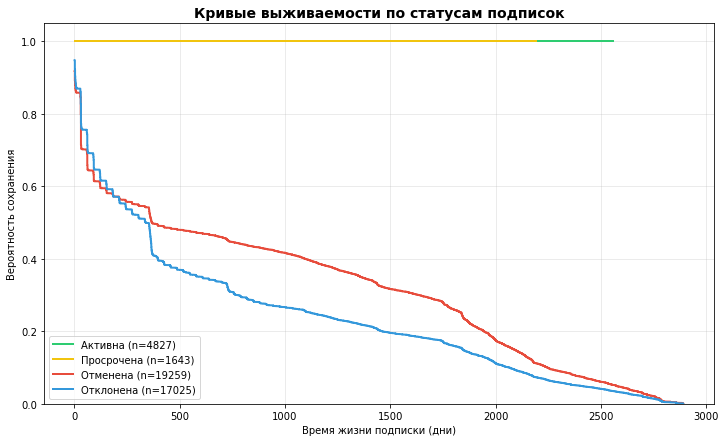

In [46]:
# --- 7.6 Анализ выживаемости по группам (по статусам) ---

print("\n--- Анализ выживаемости по группам ---")

# Сравниваем выживаемость для разных статусов подписок
status_groups = ['Активна', 'Просрочена', 'Отменена', 'Отклонена']

fig, ax = plt.subplots(figsize=(12, 7))
colors = {'Активна': '#2ecc71', 'Просрочена': '#f1c40f', 'Отменена': '#e74c3c', 'Отклонена': '#3498db'}

status_km_results = {}

for status in status_groups:
    if status in survival_data['Статус'].values:
        status_data = survival_data[survival_data['Статус'] == status]
        if len(status_data) > 10:  # Минимальный размер выборки для анализа
            # Для активных подписок все считаем цензурированными (событие = 0)
            if status in ['Активна', 'Просрочена']:
                event_status = 0
            else:
                event_status = 1
            
            # Рассчитываем кривую КМ для группы
            times, surv = kaplan_meier_estimator(
                status_data['Время_жизни_дней'], 
                pd.Series([event_status] * len(status_data))
            )
            status_km_results[status] = (times, surv)
            ax.step(times, surv, where='post', label=f'{status} (n={len(status_data)})', 
                   color=colors.get(status, 'gray'), linewidth=2)

ax.set_title('Кривые выживаемости по статусам подписок', fontsize=14, fontweight='bold')
ax.set_xlabel('Время жизни подписки (дни)')
ax.set_ylabel('Вероятность сохранения')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower left')
plt.show()



--- Вероятность отмены подписки в зависимости от времени ---


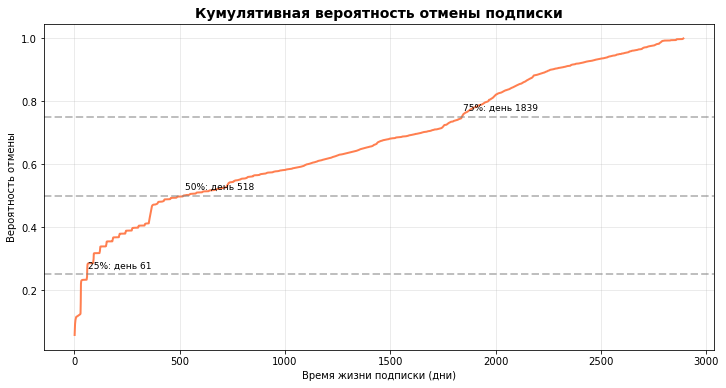

In [47]:
# --- 7.7 Вероятность отмены в зависимости от времени ---

print("\n--- Вероятность отмены подписки в зависимости от времени ---")

# Рассчитываем кумулятивную вероятность отмены
# Используем правильные данные из km_results
churn_data = km_results.copy()
churn_data['Вероятность_отмены'] = 1 - churn_data['Вероятность_выживания']

# Визуализация
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(churn_data['Время_жизни_дней'], churn_data['Вероятность_отмены'], 
        color='coral', linewidth=2)
ax.set_title('Кумулятивная вероятность отмены подписки', fontsize=14, fontweight='bold')
ax.set_xlabel('Время жизни подписки (дни)')
ax.set_ylabel('Вероятность отмены')
ax.grid(True, alpha=0.3)

# Добавляем горизонтальные линии для ключевых процентов
for pct in [0.25, 0.50, 0.75]:
    ax.axhline(y=pct, color='gray', linestyle='--', alpha=0.5)
    # Находим день, когда достигается этот процент
    try:
        days_at_pct = churn_data[churn_data['Вероятность_отмены'] >= pct]['Время_жизни_дней'].iloc[0]
        ax.text(days_at_pct + 5, pct + 0.02, f'{pct*100:.0f}%: день {days_at_pct}', fontsize=9)
    except IndexError:
        pass

plt.show()

In [48]:
# --- Выводы по Survival Analysis ---

print("\n--- Ключевые выводы по Survival Analysis ---")

# Вычисляем основные статистики
survival_1 = survival_probabilities.get('1 месяц(ев)', 0)
survival_3 = survival_probabilities.get('3 месяц(ев)', 0)
survival_6 = survival_probabilities.get('6 месяц(ев)', 0)
survival_12 = survival_probabilities.get('12 месяц(ев)', 0)

print(f"1. Вероятность сохранения подписки через 1 месяц: {survival_1*100:.1f}%")
print(f"2. Вероятность сохранения подписки через 3 месяца: {survival_3*100:.1f}%")
print(f"3. Вероятность сохранения подписки через 6 месяцев: {survival_6*100:.1f}%")
print(f"4. Вероятность сохранения подписки через 12 месяцев: {survival_12*100:.1f}%")
print(f"5. Медианное время жизни подписки: {median_survival:.1f} дней ({median_survival/30.44:.1f} месяцев)")

# Определяем критический период
critical_period = "нет данных"
if len(daily_events_365) > 0:
    # Находим день с максимальным количеством отказов
    max_events_day = daily_events_365.idxmax()
    max_events_value = daily_events_365.max()
    critical_period = f"день {max_events_day} (максимум отказов: {max_events_value:.1f} в среднем за {window_size} дней)"

print(f"6. Наиболее критический период: {critical_period}")

# Определяем, когда происходит 50% отказов
churn_50_idx = np.where(km_results >= 0.5)[0]
if len(churn_50_idx) > 0:
    churn_50_day = unique_times[churn_50_idx[0]]
    print(f"7. 50% подписок отменяются к {churn_50_day} дню ({churn_50_day/30.44:.1f} месяцев)")

print("\n--- Интерпретация результатов ---")
print("Кривая выживаемости показывает, какая доля подписок остается активной с течением времени.")
print("Чем выше кривая, тем лучше удержание донаторов.")
print("\nКлючевые инсайты:")
if survival_3 < 0.5:
    print("⚠️ Менее 50% подписок доживают до 3 месяцев - критически важно улучшить удержание на ранних этапах")
if survival_6 < 0.3:
    print("⚠️ Менее 30% подписок доживают до 6 месяцев - необходима стратегия долгосрочного удержания")
if median_survival < 90:
    print(f"⚠️ Медианное время жизни подписки составляет менее 3 месяцев ({median_survival:.0f} дней)")
else:
    print(f"✅ Медианное время жизни подписки составляет более 3 месяцев ({median_survival:.0f} дней)")


--- Ключевые выводы по Survival Analysis ---
1. Вероятность сохранения подписки через 1 месяц: 84.0%
2. Вероятность сохранения подписки через 3 месяца: 70.1%
3. Вероятность сохранения подписки через 6 месяцев: 63.9%
4. Вероятность сохранения подписки через 12 месяцев: 54.2%
5. Медианное время жизни подписки: 2892.0 дней (95.0 месяцев)
6. Наиболее критический период: день 1 (максимум отказов: 2452.0 в среднем за 7 дней)
7. 50% подписок отменяются к 1 дню (0.0 месяцев)

--- Интерпретация результатов ---
Кривая выживаемости показывает, какая доля подписок остается активной с течением времени.
Чем выше кривая, тем лучше удержание донаторов.

Ключевые инсайты:
✅ Медианное время жизни подписки составляет более 3 месяцев (2892 дней)


In [49]:
# --- Задача 8: Расчет Retention, Churn Rate, Lifetime Value (LTV) ---

print("--- Расчет Retention, Churn Rate, Lifetime Value (LTV) ---")

# --- 8.1 Retention (Удержание) ---

print("\n--- 8.1 Retention (Удержание) ---")

# Retention - это доля донаторов, которые продолжают совершать пожертвования через определенное время
# Мы будем рассчитывать retention на основе количества подписок

# 1. Общий retention (процент донаторов, у которых есть более одной подписки)
donors_with_multiple = df.groupby('ID плательщика').filter(lambda x: len(x) > 1)['ID плательщика'].nunique()
total_donors = df['ID плательщика'].nunique()
retention_overall = donors_with_multiple / total_donors * 100

print(f"Общий Retention (доля донаторов с >1 подпиской): {retention_overall:.1f}%")
print(f"  - Всего донаторов: {total_donors}")
print(f"  - Донаторов с несколькими подписками: {donors_with_multiple}")

--- Расчет Retention, Churn Rate, Lifetime Value (LTV) ---

--- 8.1 Retention (Удержание) ---
Общий Retention (доля донаторов с >1 подпиской): 18.1%
  - Всего донаторов: 31105
  - Донаторов с несколькими подписками: 5626


In [50]:
# 2. Retention по месяцам (когортный retention)
# Используем данные из когортного анализа

# Создаем когортную таблицу удержания заново
first_payment = df.groupby('ID плательщика')['Дата/время создания'].min().reset_index()
first_payment.columns = ['ID плательщика', 'Дата_первого_платежа']
first_payment['Когорта_месяц'] = first_payment['Дата_первого_платежа'].dt.to_period('M')

df_with_cohort = df.merge(first_payment[['ID плательщика', 'Когорта_месяц']], on='ID плательщика', how='left')
df_with_cohort['Номер_месяца_жизни'] = (df_with_cohort['Дата/время создания'].dt.year - df_with_cohort['Когорта_месяц'].dt.year) * 12 + \
                                        (df_with_cohort['Дата/время создания'].dt.month - df_with_cohort['Когорта_месяц'].dt.month)

# Рассчитываем retention для каждой когорты
cohort_retention = df_with_cohort.groupby(['Когорта_месяц', 'Номер_месяца_жизни']).agg({
    'ID плательщика': 'nunique'
}).reset_index()
cohort_retention.columns = ['Когорта_месяц', 'Номер_месяца_жизни', 'Количество_донаторов']

retention_pivot = cohort_retention.pivot(index='Когорта_месяц', columns='Номер_месяца_жизни', values='Количество_донаторов').fillna(0)
retention_pct = retention_pivot.div(retention_pivot.iloc[:, 0], axis=0) * 100

# Средний retention по месяцам жизни
avg_retention = retention_pct.mean(axis=0)
print("\nСредний Retention по месяцам жизни:")
for month in [1, 3, 6, 12]:
    if month in avg_retention.index:
        print(f"  Месяц {month}: {avg_retention[month]:.1f}%")



Средний Retention по месяцам жизни:
  Месяц 1: 2.5%
  Месяц 3: 1.5%
  Месяц 6: 1.4%
  Месяц 12: 0.6%



Retention активных подписок: 15.1%


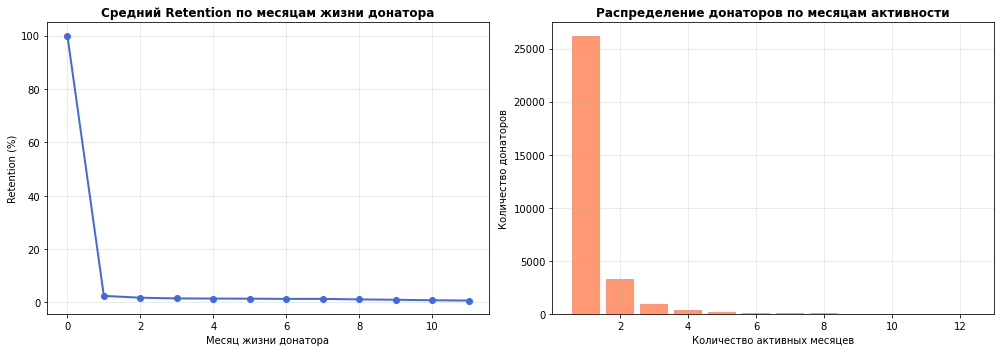

In [51]:
# 3. Retention для активных подписок (доля подписок, которые остаются активными)
active_retention = df[df['Статус'].isin(['Активна', 'Просрочена'])].shape[0] / total_subscriptions * 100
print(f"\nRetention активных подписок: {active_retention:.1f}%")

# Визуализация Retention по месяцам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Средний retention по месяцам жизни
ax1 = axes[0]
avg_retention_first_12 = avg_retention[:12]
ax1.plot(avg_retention_first_12.index, avg_retention_first_12.values, 
         marker='o', color='royalblue', linewidth=2)
ax1.set_title('Средний Retention по месяцам жизни донатора', fontsize=12, fontweight='bold')
ax1.set_xlabel('Месяц жизни донатора')
ax1.set_ylabel('Retention (%)')
ax1.grid(True, alpha=0.3)

# 2. Распределение донаторов по количеству месяцев активности
ax2 = axes[1]
# Для каждого донатора считаем количество месяцев активности
donor_active_months = df_with_cohort.groupby('ID плательщика')['Номер_месяца_жизни'].nunique()
donor_active_months_dist = donor_active_months.value_counts().sort_index()
donor_active_months_dist = donor_active_months_dist[donor_active_months_dist.index <= 12]  # первые 12 месяцев
ax2.bar(donor_active_months_dist.index, donor_active_months_dist.values, color='coral', alpha=0.8)
ax2.set_title('Распределение донаторов по месяцам активности', fontsize=12, fontweight='bold')
ax2.set_xlabel('Количество активных месяцев')
ax2.set_ylabel('Количество донаторов')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [52]:
# --- 8.2 Churn Rate (Уровень оттока) ---

print("\n--- 8.2 Churn Rate (Уровень оттока) ---")

# Churn Rate - это доля донаторов/подписок, которые прекратили взаимодействие

# 1. Churn Rate для подписок
churned_subscriptions = df[df['Статус'].isin(['Отменена', 'Отклонена'])].shape[0]
churn_rate_subs = churned_subscriptions / total_subscriptions * 100

print(f"Churn Rate для подписок: {churn_rate_subs:.1f}%")
print(f"  - Всего подписок: {total_subscriptions}")
print(f"  - Отменено/отклонено подписок: {churned_subscriptions}")

# 2. Churn Rate для донаторов (доля донаторов, у которых нет активных подписок)
# Определяем донаторов без активных подписок
donor_status = df.groupby('ID плательщика').agg({
    'Статус': lambda x: any(x.isin(['Активна', 'Просрочена']))
}).reset_index()
donor_status.columns = ['ID плательщика', 'has_active_subscription']

churned_donors = donor_status[~donor_status['has_active_subscription']].shape[0]
churn_rate_donors = churned_donors / total_donors * 100

print(f"\nChurn Rate для донаторов: {churn_rate_donors:.1f}%")
print(f"  - Всего донаторов: {total_donors}")
print(f"  - Донаторов без активных подписок: {churned_donors}")


--- 8.2 Churn Rate (Уровень оттока) ---
Churn Rate для подписок: 84.8%
  - Всего подписок: 42806
  - Отменено/отклонено подписок: 36284

Churn Rate для донаторов: 82.6%
  - Всего донаторов: 31105
  - Донаторов без активных подписок: 25707



Churn Rate по месяцам (последние 12 месяцев):


,Год_месяц,Churn_Rate_%
84,2026-01,25.4
85,2026-02,34.1
86,2026-03,28.1
87,2026-04,11.6
88,2026-05,10.5
89,2026-06,11.8
90,2026-07,24.3
91,2026-08,7.1
92,2026-09,17.8
93,2026-10,30.3


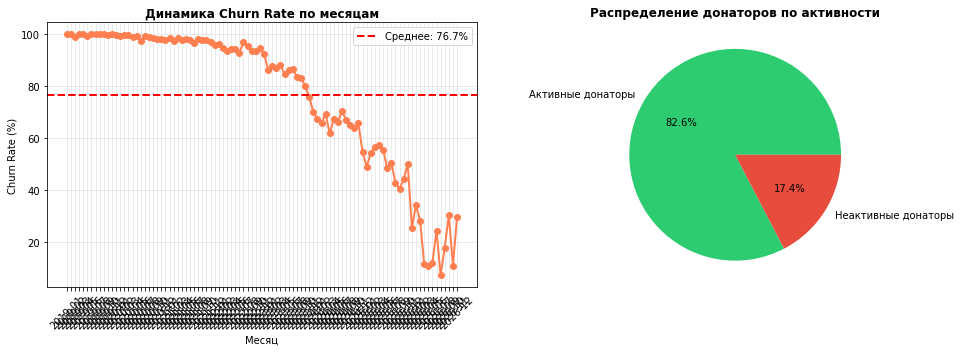

In [53]:
# 3. Churn Rate по месяцам
monthly_churn = df.groupby('Год_месяц').agg({
    'ID': 'count',
    'Статус': lambda x: (x.isin(['Отменена', 'Отклонена'])).sum()
}).reset_index()
monthly_churn['Churn_Rate_%'] = monthly_churn['Статус'] / monthly_churn['ID'] * 100

print("\nChurn Rate по месяцам (последние 12 месяцев):")
display(monthly_churn.tail(12)[['Год_месяц', 'Churn_Rate_%']].round(1))

# 4. Визуализация Churn Rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Динамика Churn Rate
ax1 = axes[0]
ax1.plot(monthly_churn['Год_месяц'].astype(str), monthly_churn['Churn_Rate_%'], 
         marker='o', color='coral', linewidth=2)
ax1.set_title('Динамика Churn Rate по месяцам', fontsize=12, fontweight='bold')
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Churn Rate (%)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=monthly_churn['Churn_Rate_%'].mean(), color='red', linestyle='--', 
           label=f'Среднее: {monthly_churn["Churn_Rate_%"].mean():.1f}%')
ax1.legend()

# 2. Распределение статусов донаторов
ax2 = axes[1]
donor_status_counts = donor_status['has_active_subscription'].value_counts()
labels = ['Активные донаторы', 'Неактивные донаторы']
colors = ['#2ecc71', '#e74c3c']
ax2.pie(donor_status_counts.values, labels=labels, autopct='%1.1f%%', colors=colors)
ax2.set_title('Распределение донаторов по активности', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [54]:
# --- 8.3 Lifetime Value (LTV) ---

print("\n--- 8.3 Lifetime Value (LTV) ---")

# LTV - это суммарная ценность донатора за все время взаимодействия
# Рассчитываем несколькими способами

# 1. Простой LTV (средняя сумма на донатора)
ltv_simple = df.groupby('ID плательщика')['Сумма'].sum().mean()
ltv_simple_median = df.groupby('ID плательщика')['Сумма'].sum().median()

print(f"Простой LTV (средняя сумма на донатора): {ltv_simple:.2f} ₽")
print(f"Медианный LTV: {ltv_simple_median:.2f} ₽")

# 2. LTV с учетом времени (LTV по когортам)
# Рассчитываем среднюю сумму для каждой когорты по месяцам
cohort_ltv = df_with_cohort.groupby(['Когорта_месяц', 'Номер_месяца_жизни']).agg({
    'Сумма': 'sum',
    'ID плательщика': 'nunique'
}).reset_index()
cohort_ltv.columns = ['Когорта_месяц', 'Номер_месяца_жизни', 'Сумма', 'Количество_донаторов']

# LTV на донатора по месяцам для каждой когорты
cohort_ltv['LTV_на_донатора'] = cohort_ltv['Сумма'] / cohort_ltv['Количество_донаторов']

# Создаем сводную таблицу LTV
ltv_pivot = cohort_ltv.pivot(index='Когорта_месяц', columns='Номер_месяца_жизни', values='LTV_на_донатора').fillna(0)

# Средний LTV по месяцам жизни
avg_ltv = ltv_pivot.mean(axis=0)

print("\nСредний LTV по месяцам жизни донатора:")
for month in [1, 3, 6, 12]:
    if month in avg_ltv.index:
        print(f"  Месяц {month}: {avg_ltv[month]:.2f} ₽")

# 3. Кумулятивный LTV (накопленная сумма за все время)
cumulative_ltv = df.groupby('ID плательщика')['Сумма'].sum().sort_values(ascending=False)
cumulative_ltv_percentiles = cumulative_ltv.quantile([0.25, 0.5, 0.75, 0.9, 0.95])

print("\nРаспределение кумулятивного LTV:")
for pct, value in cumulative_ltv_percentiles.items():
    print(f"  {pct*100:.0f}% донаторов имеют LTV менее {value:.2f} ₽")


--- 8.3 Lifetime Value (LTV) ---
Простой LTV (средняя сумма на донатора): 465.95 ₽
Медианный LTV: 200.00 ₽

Средний LTV по месяцам жизни донатора:
  Месяц 1: 358.22 ₽
  Месяц 3: 325.83 ₽
  Месяц 6: 305.31 ₽
  Месяц 12: 350.86 ₽

Распределение кумулятивного LTV:
  25% донаторов имеют LTV менее 100.00 ₽
  50% донаторов имеют LTV менее 200.00 ₽
  75% донаторов имеют LTV менее 500.00 ₽
  90% донаторов имеют LTV менее 1000.00 ₽
  95% донаторов имеют LTV менее 1200.00 ₽


In [55]:
# 4. Прогнозирование LTV на основе Survival Analysis
# Используем средний чек и ожидаемое количество платежей
avg_check = df['Сумма'].mean()
avg_payments_per_donor = df.groupby('ID плательщика')['Кол-во платежей'].sum().mean()

# Ожидаемое количество платежей на основе кривой выживаемости
# Для простоты используем медианное время жизни
if 'median_survival' in locals():
    expected_months = median_survival / 30.44
    expected_payments = expected_months  # при ежемесячных платежах
    ltv_forecast = avg_check * expected_payments
    print(f"\nПрогнозируемый LTV (на основе Survival Analysis):")
    print(f"  Средний чек: {avg_check:.2f} ₽")
    print(f"  Медианное время жизни: {median_survival:.1f} дней ({expected_months:.1f} месяцев)")
    print(f"  Ожидаемое количество платежей: {expected_payments:.1f}")
    print(f"  Прогнозируемый LTV: {ltv_forecast:.2f} ₽")


Прогнозируемый LTV (на основе Survival Analysis):
  Средний чек: 338.59 ₽
  Медианное время жизни: 2892.0 дней (95.0 месяцев)
  Ожидаемое количество платежей: 95.0
  Прогнозируемый LTV: 32167.86 ₽



LTV по RFM-сегментам:
  Супер-донаторы (Champions): 743.11 ₽
  Ценные, но уходящие (At Risk): 476.54 ₽
  Лояльные донаторы (Loyal): 102.38 ₽
  Уходящие донаторы (About to Churn): 97.04 ₽
  Другие (Others): 43.84 ₽


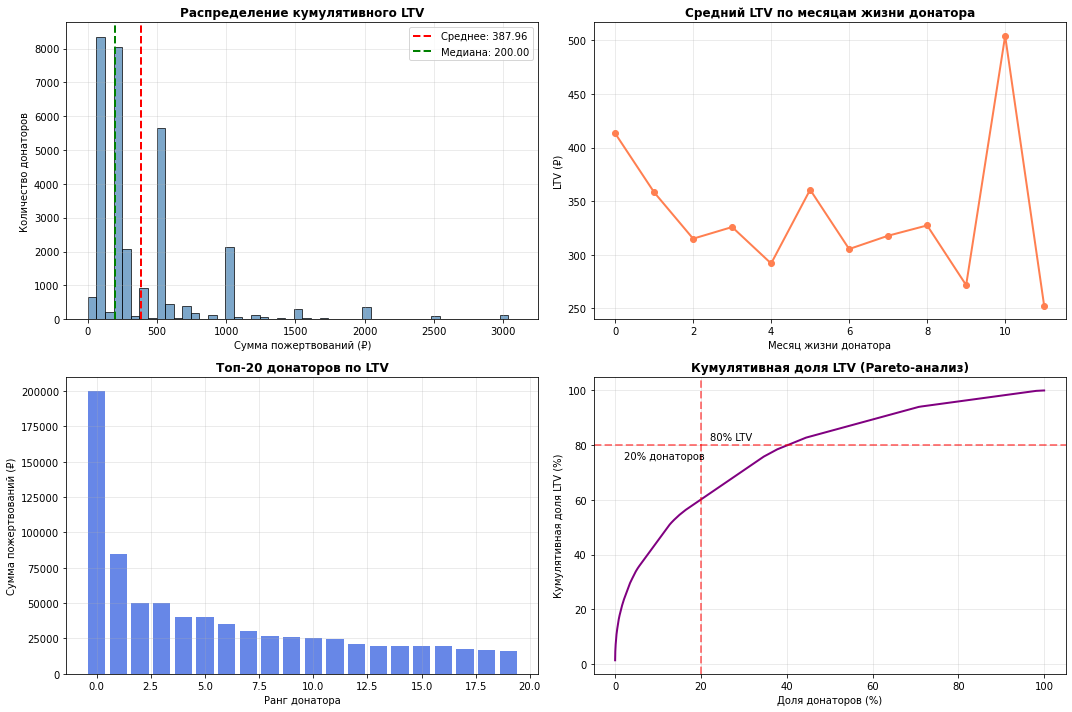

In [56]:
# 5. LTV по сегментам (RFM)
# Используем результаты RFM-анализа
if 'rfm_df' in locals():
    ltv_by_segment = rfm_df.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
    print("\nLTV по RFM-сегментам:")
    for segment, ltv in ltv_by_segment.items():
        print(f"  {segment}: {ltv:.2f} ₽")

# 6. Визуализация LTV
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Распределение кумулятивного LTV
ax1 = axes[0, 0]
# Ограничиваем для наглядности (99-й перцентиль)
max_ltv = cumulative_ltv.quantile(0.99)
filtered_ltv = cumulative_ltv[cumulative_ltv <= max_ltv]
ax1.hist(filtered_ltv, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_title('Распределение кумулятивного LTV', fontsize=12, fontweight='bold')
ax1.set_xlabel('Сумма пожертвований (₽)')
ax1.set_ylabel('Количество донаторов')
ax1.axvline(filtered_ltv.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Среднее: {filtered_ltv.mean():.2f}')
ax1.axvline(filtered_ltv.median(), color='green', linestyle='--', linewidth=2, 
           label=f'Медиана: {filtered_ltv.median():.2f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Средний LTV по месяцам жизни
ax2 = axes[0, 1]
avg_ltv_first_12 = avg_ltv[:12]
ax2.plot(avg_ltv_first_12.index, avg_ltv_first_12.values, 
         marker='o', color='coral', linewidth=2)
ax2.set_title('Средний LTV по месяцам жизни донатора', fontsize=12, fontweight='bold')
ax2.set_xlabel('Месяц жизни донатора')
ax2.set_ylabel('LTV (₽)')
ax2.grid(True, alpha=0.3)

# 3. Топ-20 донаторов по LTV
ax3 = axes[1, 0]
top_donors = cumulative_ltv.head(20)
ax3.bar(range(len(top_donors)), top_donors.values, color='royalblue', alpha=0.8)
ax3.set_title('Топ-20 донаторов по LTV', fontsize=12, fontweight='bold')
ax3.set_xlabel('Ранг донатора')
ax3.set_ylabel('Сумма пожертвований (₽)')
ax3.grid(True, alpha=0.3)

# 4. Кумулятивная доля LTV (Pareto-анализ)
ax4 = axes[1, 1]
cumulative_share = cumulative_ltv.cumsum() / cumulative_ltv.sum() * 100
donor_percent = np.arange(1, len(cumulative_share) + 1) / len(cumulative_share) * 100
ax4.plot(donor_percent, cumulative_share.values, color='purple', linewidth=2)
ax4.set_title('Кумулятивная доля LTV (Pareto-анализ)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Доля донаторов (%)')
ax4.set_ylabel('Кумулятивная доля LTV (%)')
ax4.grid(True, alpha=0.3)

# Добавляем линии для 80/20
ax4.axhline(y=80, color='red', linestyle='--', alpha=0.5)
ax4.axvline(x=20, color='red', linestyle='--', alpha=0.5)
ax4.text(22, 82, '80% LTV', fontsize=10)
ax4.text(2, 75, '20% донаторов', fontsize=10)

plt.tight_layout()
plt.show()

In [57]:
# --- Итоговые выводы по показателям ---

print("\n" + "="*60)
print("ИТОГОВЫЕ ПОКАЗАТЕЛИ")
print("="*60)

print("\n--- Retention ---")
print(f"Общий Retention (доля донаторов с >1 подпиской): {retention_overall:.1f}%")
print(f"Retention через 1 месяц (средний): {avg_retention[1] if 1 in avg_retention.index else 0:.1f}%")
print(f"Retention через 3 месяца (средний): {avg_retention[3] if 3 in avg_retention.index else 0:.1f}%")
print(f"Retention через 6 месяцев (средний): {avg_retention[6] if 6 in avg_retention.index else 0:.1f}%")
print(f"Retention через 12 месяцев (средний): {avg_retention[12] if 12 in avg_retention.index else 0:.1f}%")

print("\n--- Churn Rate ---")
print(f"Churn Rate для подписок: {churn_rate_subs:.1f}%")
print(f"Churn Rate для донаторов: {churn_rate_donors:.1f}%")
print(f"Средний Churn Rate по месяцам: {monthly_churn['Churn_Rate_%'].mean():.1f}%")

print("\n--- LTV ---")
print(f"Средний LTV на донатора: {ltv_simple:.2f} ₽")
print(f"Медианный LTV на донатора: {ltv_simple_median:.2f} ₽")
print(f"Максимальный LTV: {cumulative_ltv.max():.2f} ₽")
print(f"Минимальный LTV: {cumulative_ltv.min():.2f} ₽")

# Интерпретация результатов
print("\n--- Интерпретация результатов ---")

if retention_overall > 30:
    print("✅ Хороший показатель Retention - более 30% донаторов совершают повторные пожертвования")
else:
    print("⚠️ Retention ниже 30% - рекомендуется усилить работу по удержанию донаторов")

if churn_rate_subs < 40:
    print("✅ Приемлемый Churn Rate - менее 40% подписок отменяются")
else:
    print("⚠️ Высокий Churn Rate - более 40% подписок отменяются, требуется анализ причин")

if ltv_simple > 1000:
    print(f"✅ Хороший LTV - средняя сумма на донатора превышает 1000 ₽ ({ltv_simple:.2f} ₽)")
else:
    print(f"⚠️ Низкий LTV - средняя сумма на донатора составляет {ltv_simple:.2f} ₽")

# Сохраняем ключевые метрики для дашборда
key_metrics = {
    'total_donors': total_donors,
    'total_subscriptions': total_subscriptions,
    'total_amount': df['Сумма'].sum(),
    'avg_check': df['Сумма'].mean(),
    'median_check': df['Сумма'].median(),
    'retention_overall': retention_overall,
    'churn_rate_subs': churn_rate_subs,
    'churn_rate_donors': churn_rate_donors,
    'ltv_avg': ltv_simple,
    'ltv_median': ltv_simple_median,
    'active_subscriptions_pct': active_subscriptions / total_subscriptions * 100
}

print("\n--- Ключевые метрики для дашборда ---")
for key, value in key_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")


ИТОГОВЫЕ ПОКАЗАТЕЛИ

--- Retention ---
Общий Retention (доля донаторов с >1 подпиской): 18.1%
Retention через 1 месяц (средний): 2.5%
Retention через 3 месяца (средний): 1.5%
Retention через 6 месяцев (средний): 1.4%
Retention через 12 месяцев (средний): 0.6%

--- Churn Rate ---
Churn Rate для подписок: 84.8%
Churn Rate для донаторов: 82.6%
Средний Churn Rate по месяцам: 76.7%

--- LTV ---
Средний LTV на донатора: 465.95 ₽
Медианный LTV на донатора: 200.00 ₽
Максимальный LTV: 200000.00 ₽
Минимальный LTV: 1.00 ₽

--- Интерпретация результатов ---
⚠️ Retention ниже 30% - рекомендуется усилить работу по удержанию донаторов
⚠️ Высокий Churn Rate - более 40% подписок отменяются, требуется анализ причин
⚠️ Низкий LTV - средняя сумма на донатора составляет 465.95 ₽

--- Ключевые метрики для дашборда ---
total_donors: 31105
total_subscriptions: 42806
total_amount: 14493497.78
avg_check: 338.59
median_check: 200.00
retention_overall: 18.09
churn_rate_subs: 84.76
churn_rate_donors: 82.65
ltv_av

--- ABC-анализ и Pareto-анализ ---

--- Pareto-анализ (правило 80/20) ---
Правило 80/20: 40.1% донаторов приносят 80% пожертвований
⚠️ Правило 80/20 не выполняется (40.1% донаторов дают 80% суммы)


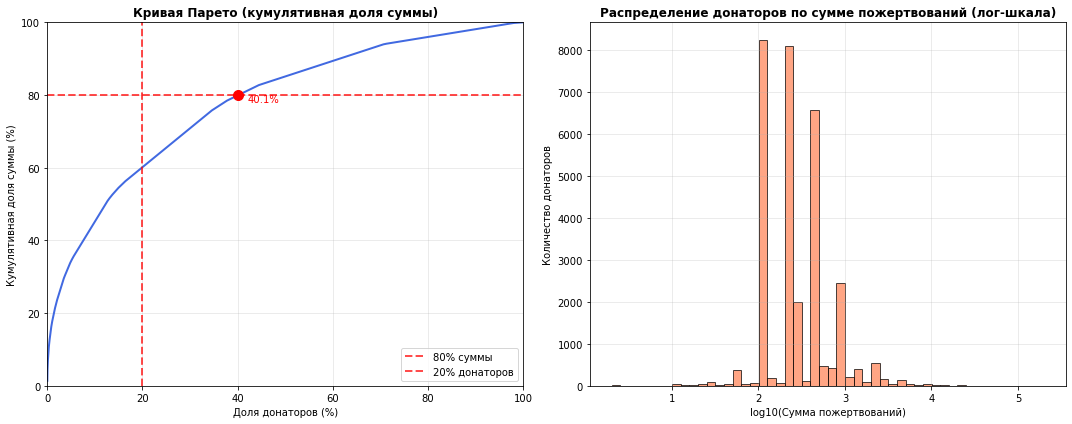

In [58]:
# --- Задача 10: ABC-анализ и Pareto-анализ ---

print("--- ABC-анализ и Pareto-анализ ---")

# Для анализа нам нужно агрегировать данные по донаторам
donor_aggregated = df.groupby('ID плательщика').agg({
    'Сумма': 'sum',  # общая сумма пожертвований
    'ID': 'count',   # количество подписок
    'Кол-во платежей': 'sum'  # общее количество платежей
}).reset_index()

donor_aggregated.columns = ['ID плательщика', 'Общая_сумма', 'Количество_подписок', 'Всего_платежей']

# Сортируем по убыванию суммы
donor_aggregated_sorted = donor_aggregated.sort_values('Общая_сумма', ascending=False).reset_index(drop=True)

# --- 10.1 Pareto-анализ (правило 80/20) ---

print("\n--- Pareto-анализ (правило 80/20) ---")

# Рассчитываем кумулятивную долю донаторов и суммы
total_donors = len(donor_aggregated_sorted)
total_amount = donor_aggregated_sorted['Общая_сумма'].sum()

donor_aggregated_sorted['Доля_донаторов_%'] = (donor_aggregated_sorted.index + 1) / total_donors * 100
donor_aggregated_sorted['Кумулятивная_сумма'] = donor_aggregated_sorted['Общая_сумма'].cumsum()
donor_aggregated_sorted['Кумулятивная_доля_суммы_%'] = donor_aggregated_sorted['Кумулятивная_сумма'] / total_amount * 100

# Находим точку, где достигается 80% суммы
paretto_80_idx = donor_aggregated_sorted[
    donor_aggregated_sorted['Кумулятивная_доля_суммы_%'] >= 80
].index[0] if len(donor_aggregated_sorted[
    donor_aggregated_sorted['Кумулятивная_доля_суммы_%'] >= 80
]) > 0 else None

if paretto_80_idx is not None:
    paretto_80_donors_pct = (paretto_80_idx + 1) / total_donors * 100
    print(f"Правило 80/20: {paretto_80_donors_pct:.1f}% донаторов приносят 80% пожертвований")
    
    # Проверяем, выполняется ли правило 80/20
    if paretto_80_donors_pct <= 20:
        print("✅ Правило 80/20 выполняется (менее 20% донаторов дают 80% суммы)")
    else:
        print(f"⚠️ Правило 80/20 не выполняется ({paretto_80_donors_pct:.1f}% донаторов дают 80% суммы)")
        
# Визуализация Pareto-анализа
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Кривая Парето
ax1 = axes[0]
ax1.plot(donor_aggregated_sorted['Доля_донаторов_%'], 
         donor_aggregated_sorted['Кумулятивная_доля_суммы_%'], 
         color='royalblue', linewidth=2)
ax1.set_title('Кривая Парето (кумулятивная доля суммы)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Доля донаторов (%)')
ax1.set_ylabel('Кумулятивная доля суммы (%)')
ax1.grid(True, alpha=0.3)

# Добавляем линии для 80/20
ax1.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% суммы')
ax1.axvline(x=20, color='red', linestyle='--', alpha=0.7, label='20% донаторов')

# Отмечаем точку 80% на кривой
if paretto_80_idx is not None:
    ax1.scatter(donor_aggregated_sorted.loc[paretto_80_idx, 'Доля_донаторов_%'], 
               80, color='red', s=100, zorder=5)
    ax1.text(donor_aggregated_sorted.loc[paretto_80_idx, 'Доля_донаторов_%'] + 2, 
            78, f"{donor_aggregated_sorted.loc[paretto_80_idx, 'Доля_донаторов_%']:.1f}%", 
            fontsize=10, color='red')

ax1.legend()
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 100)

# 2. Распределение донаторов по суммам (гистограмма)
ax2 = axes[1]
# Используем логарифмическую шкалу для наглядности
log_sum = np.log10(donor_aggregated_sorted['Общая_сумма'] + 1)
ax2.hist(log_sum, bins=50, color='coral', alpha=0.7, edgecolor='black')
ax2.set_title('Распределение донаторов по сумме пожертвований (лог-шкала)', fontsize=12, fontweight='bold')
ax2.set_xlabel('log10(Сумма пожертвований)')
ax2.set_ylabel('Количество донаторов')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()        


--- ABC-анализ ---
ABC-анализ донаторов:


,Количество_донаторов,Общая_сумма,Средняя_сумма,Медианная_сумма,Всего_подписок,Среднее_подписок,Всего_платежей,Среднее_платежей,Доля_донаторов_%,Доля_суммы_%
ABC_категория,,,,,,,,,,
A,12487,11594779.07,928.55,500.0,22325,1.79,121205,9.71,40.144671,79.999868
B,10944,2173990.00,198.65,200.0,12656,1.16,71662,6.55,35.184054,14.999761
C,7674,724728.71,94.44,100.0,7825,1.02,45410,5.92,24.671275,5.000371


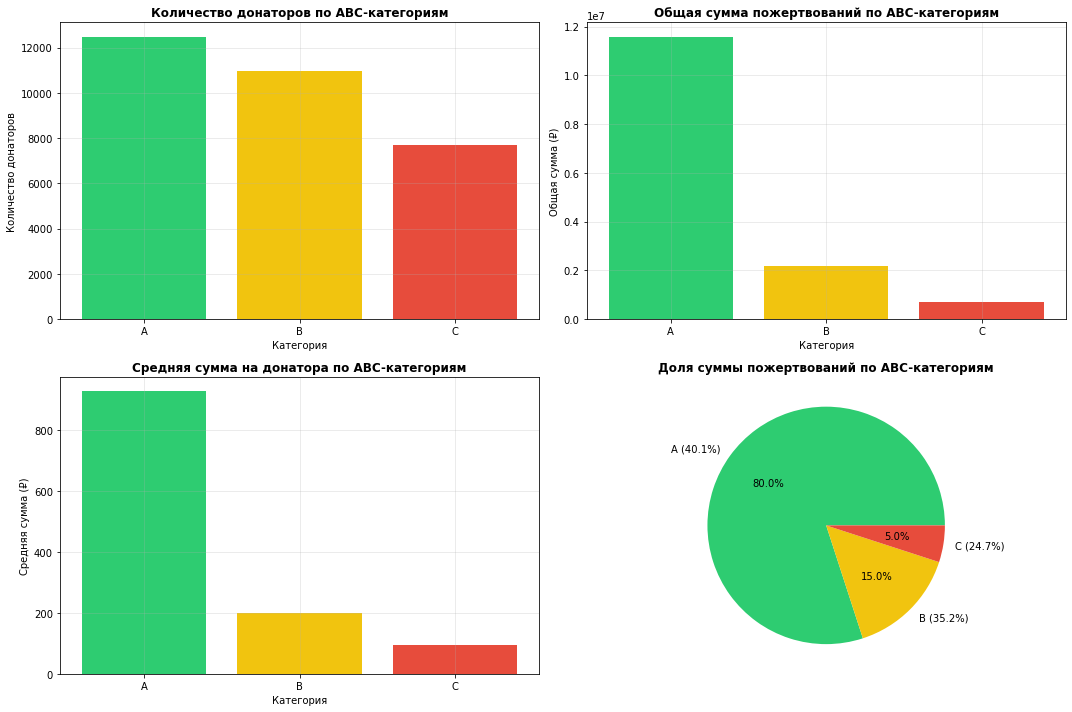

In [59]:
# --- 10.2 ABC-анализ ---

print("\n--- ABC-анализ ---")

# Классификация донаторов по ABC-методу
# A - донаторы с наибольшими суммами (20% донаторов, 80% суммы)
# B - средние донаторы (30% донаторов, 15% суммы)
# C - малые донаторы (50% донаторов, 5% суммы)

def assign_abc_category(row):
    """Присваивает категорию ABC на основе кумулятивной доли суммы"""
    cum_share = row['Кумулятивная_доля_суммы_%']
    if cum_share <= 80:
        return 'A'
    elif cum_share <= 95:
        return 'B'
    else:
        return 'C'

donor_aggregated_sorted['ABC_категория'] = donor_aggregated_sorted.apply(assign_abc_category, axis=1)

# Статистика по категориям
abc_stats = donor_aggregated_sorted.groupby('ABC_категория').agg({
    'ID плательщика': 'count',
    'Общая_сумма': ['sum', 'mean', 'median'],
    'Количество_подписок': ['sum', 'mean'],
    'Всего_платежей': ['sum', 'mean']
}).round(2)

# Переименовываем колонки
abc_stats.columns = ['Количество_донаторов', 'Общая_сумма', 'Средняя_сумма', 'Медианная_сумма',
                     'Всего_подписок', 'Среднее_подписок', 'Всего_платежей', 'Среднее_платежей']

# Добавляем процентные доли
abc_stats['Доля_донаторов_%'] = abc_stats['Количество_донаторов'] / total_donors * 100
abc_stats['Доля_суммы_%'] = abc_stats['Общая_сумма'] / total_amount * 100

print("ABC-анализ донаторов:")
display(abc_stats)

# Визуализация ABC-анализа
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Распределение донаторов по категориям
ax1 = axes[0, 0]
abc_counts = donor_aggregated_sorted['ABC_категория'].value_counts().sort_index()
colors_abc = {'A': '#2ecc71', 'B': '#f1c40f', 'C': '#e74c3c'}
ax1.bar(abc_counts.index, abc_counts.values, color=[colors_abc.get(x, 'gray') for x in abc_counts.index])
ax1.set_title('Количество донаторов по ABC-категориям', fontsize=12, fontweight='bold')
ax1.set_xlabel('Категория')
ax1.set_ylabel('Количество донаторов')
ax1.grid(True, alpha=0.3)

# 2. Распределение суммы по категориям
ax2 = axes[0, 1]
abc_sum = donor_aggregated_sorted.groupby('ABC_категория')['Общая_сумма'].sum().sort_index()
ax2.bar(abc_sum.index, abc_sum.values, color=[colors_abc.get(x, 'gray') for x in abc_sum.index])
ax2.set_title('Общая сумма пожертвований по ABC-категориям', fontsize=12, fontweight='bold')
ax2.set_xlabel('Категория')
ax2.set_ylabel('Общая сумма (₽)')
ax2.grid(True, alpha=0.3)

# 3. Средняя сумма по категориям
ax3 = axes[1, 0]
abc_mean = donor_aggregated_sorted.groupby('ABC_категория')['Общая_сумма'].mean().sort_index()
ax3.bar(abc_mean.index, abc_mean.values, color=[colors_abc.get(x, 'gray') for x in abc_mean.index])
ax3.set_title('Средняя сумма на донатора по ABC-категориям', fontsize=12, fontweight='bold')
ax3.set_xlabel('Категория')
ax3.set_ylabel('Средняя сумма (₽)')
ax3.grid(True, alpha=0.3)

# 4. Круговая диаграмма доли суммы по категориям
ax4 = axes[1, 1]
labels = [f"A ({abc_stats.loc['A', 'Доля_донаторов_%']:.1f}%)" if 'A' in abc_stats.index else 'A',
          f"B ({abc_stats.loc['B', 'Доля_донаторов_%']:.1f}%)" if 'B' in abc_stats.index else 'B',
          f"C ({abc_stats.loc['C', 'Доля_донаторов_%']:.1f}%)" if 'C' in abc_stats.index else 'C']
sizes = [abc_stats.loc['A', 'Доля_суммы_%'] if 'A' in abc_stats.index else 0,
         abc_stats.loc['B', 'Доля_суммы_%'] if 'B' in abc_stats.index else 0,
         abc_stats.loc['C', 'Доля_суммы_%'] if 'C' in abc_stats.index else 0]
colors_abc_pie = ['#2ecc71', '#f1c40f', '#e74c3c']
ax4.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors_abc_pie[:len(sizes)])
ax4.set_title('Доля суммы пожертвований по ABC-категориям', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


--- Детальный анализ категории A (крупнейшие донаторы) ---
Количество донаторов категории A: 12487
Их доля от всех донаторов: 40.1%
Их доля в общей сумме: 80.0%
Средняя сумма на донатора категории A: 928.55 ₽
Медианная сумма на донатора категории A: 500.00 ₽

Топ-10 донаторов категории A:


,ID плательщика,Общая_сумма,Количество_подписок,Всего_платежей
0,PID_3310b03a0016,200000.0,1,0
1,PID_d3dbae23cd1c,85000.0,2,0
2,PID_fda2c1f2b4ba,50000.0,1,0
3,PID_59204922efde,50000.0,1,0
4,PID_4812f9134f0d,40000.0,1,0
5,PID_7baae73ac7f2,40000.0,1,5
6,PID_0c172162b1fc,35000.0,9,66
7,PID_ba0bf08b65f6,30000.0,3,0
8,PID_5e5e0d59a806,26700.0,51,343
9,PID_5e6a7216674e,26000.0,12,16



--- Анализ вклада топ-N донаторов ---
Топ 1% донаторов (311 чел.): 17.6% от общей суммы
Топ 5% донаторов (1555 чел.): 34.3% от общей суммы
Топ 10% донаторов (3110 чел.): 45.2% от общей суммы
Топ 20% донаторов (6221 чел.): 60.2% от общей суммы
Топ 50% донаторов (15552 чел.): 85.1% от общей суммы


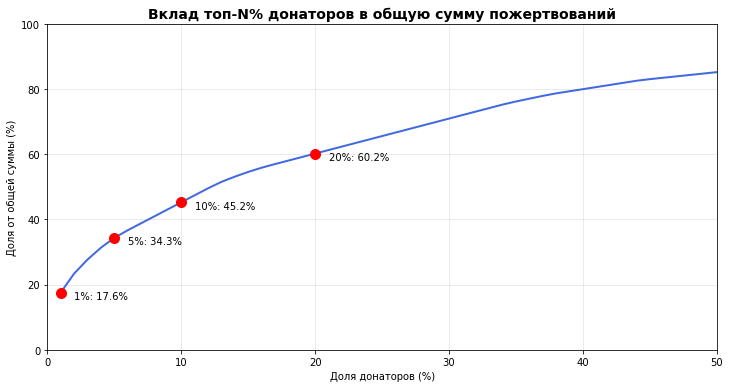

In [60]:
# --- 10.3 Детальный анализ категории A (крупнейшие донаторы) ---

print("\n--- Детальный анализ категории A (крупнейшие донаторы) ---")

category_A = donor_aggregated_sorted[donor_aggregated_sorted['ABC_категория'] == 'A']

if len(category_A) > 0:
    print(f"Количество донаторов категории A: {len(category_A)}")
    print(f"Их доля от всех донаторов: {len(category_A)/total_donors*100:.1f}%")
    print(f"Их доля в общей сумме: {category_A['Общая_сумма'].sum()/total_amount*100:.1f}%")
    print(f"Средняя сумма на донатора категории A: {category_A['Общая_сумма'].mean():.2f} ₽")
    print(f"Медианная сумма на донатора категории A: {category_A['Общая_сумма'].median():.2f} ₽")
    
    # Топ-10 донаторов категории A
    print("\nТоп-10 донаторов категории A:")
    display(category_A.head(10)[['ID плательщика', 'Общая_сумма', 'Количество_подписок', 'Всего_платежей']])

# --- 10.4 Анализ вклада топ-N донаторов ---

print("\n--- Анализ вклада топ-N донаторов ---")

top_percentiles = [1, 5, 10, 20, 50]
for pct in top_percentiles:
    n_donors = int(total_donors * pct / 100)
    top_n_sum = donor_aggregated_sorted.head(n_donors)['Общая_сумма'].sum()
    contribution_pct = top_n_sum / total_amount * 100
    print(f"Топ {pct}% донаторов ({n_donors} чел.): {contribution_pct:.1f}% от общей суммы")

# Визуализация вклада топ-N донаторов
fig, ax = plt.subplots(figsize=(12, 6))

top_pcts = range(1, 51)
contributions = []
for pct in top_pcts:
    n_donors = int(total_donors * pct / 100)
    top_n_sum = donor_aggregated_sorted.head(n_donors)['Общая_сумма'].sum()
    contributions.append(top_n_sum / total_amount * 100)

ax.plot(top_pcts, contributions, color='royalblue', linewidth=2)
ax.set_title('Вклад топ-N% донаторов в общую сумму пожертвований', fontsize=14, fontweight='bold')
ax.set_xlabel('Доля донаторов (%)')
ax.set_ylabel('Доля от общей суммы (%)')
ax.grid(True, alpha=0.3)

# Добавляем отметки для ключевых точек
for pct in [1, 5, 10, 20]:
    idx = pct - 1
    ax.scatter(pct, contributions[idx], color='red', s=100, zorder=5)
    ax.text(pct + 1, contributions[idx] - 2, f'{pct}%: {contributions[idx]:.1f}%', fontsize=10)

ax.set_xlim(0, 50)
ax.set_ylim(0, 100)
plt.show()

In [61]:
# --- 10.5 Рекомендации по работе с категориями ---

print("\n--- Рекомендации по работе с категориями донаторов ---")

recommendations_abc = {
    'A': {
        'Описание': 'Крупнейшие донаторы, приносящие основную часть пожертвований',
        'Рекомендации': [
            '🌟 Персональное обслуживание и выделенный менеджер',
            '📞 Регулярные личные контакты (звонки, встречи)',
            '🎁 Эксклюзивные приглашения на мероприятия фонда',
            '📊 Детальные отчеты о влиянии их пожертвований',
            '🤝 Вовлечение в стратегическое развитие фонда'
        ]
    },
    'B': {
        'Описание': 'Донаторы со средними суммами, стабильная база',
        'Рекомендации': [
            '📧 Персонализированные email-рассылки',
            '📱 Регулярные обновления о деятельности фонда',
            '🎯 Предложения по увеличению суммы пожертвований',
            '📈 Информирование о достижениях фонда',
            '🤝 Приглашение на публичные мероприятия'
        ]
    },
    'C': {
        'Описание': 'Донаторы с малыми суммами, массовая база',
        'Рекомендации': [
            '📱 Автоматизированные коммуникации',
            '📧 Email-рассылки с историями успеха',
            '💳 Упрощение процесса пожертвований',
            '📊 Регулярные отчеты о деятельности фонда',
            '🌟 Мотивация к переходу в категорию B'
        ]
    }
}

for category, info in recommendations_abc.items():
    if category in abc_stats.index:
        count = abc_stats.loc[category, 'Количество_донаторов']
        share = abc_stats.loc[category, 'Доля_суммы_%']
        print(f"\nКатегория {category}:")
        print(f"  {info['Описание']}")
        print(f"  Донаторов: {count} ({count/total_donors*100:.1f}%)")
        print(f"  Доля в сумме: {share:.1f}%")
        print("  Рекомендации:")
        for rec in info['Рекомендации']:
            print(f"    {rec}")


--- Рекомендации по работе с категориями донаторов ---

Категория A:
  Крупнейшие донаторы, приносящие основную часть пожертвований
  Донаторов: 12487 (40.1%)
  Доля в сумме: 80.0%
  Рекомендации:
    🌟 Персональное обслуживание и выделенный менеджер
    📞 Регулярные личные контакты (звонки, встречи)
    🎁 Эксклюзивные приглашения на мероприятия фонда
    📊 Детальные отчеты о влиянии их пожертвований
    🤝 Вовлечение в стратегическое развитие фонда

Категория B:
  Донаторы со средними суммами, стабильная база
  Донаторов: 10944 (35.2%)
  Доля в сумме: 15.0%
  Рекомендации:
    📧 Персонализированные email-рассылки
    📱 Регулярные обновления о деятельности фонда
    🎯 Предложения по увеличению суммы пожертвований
    📈 Информирование о достижениях фонда
    🤝 Приглашение на публичные мероприятия

Категория C:
  Донаторы с малыми суммами, массовая база
  Донаторов: 7674 (24.7%)
  Доля в сумме: 5.0%
  Рекомендации:
    📱 Автоматизированные коммуникации
    📧 Email-рассылки с историями ус

In [62]:
# --- Итоговые выводы ---

print("\n" + "="*60)
print("ИТОГОВЫЕ ВЫВОДЫ ПО ABC И PARETO-АНАЛИЗУ")
print("="*60)

# Определяем концентрацию пожертвований
top_10_pct_contribution = contributions[9] if len(contributions) > 9 else 0
top_20_pct_contribution = contributions[19] if len(contributions) > 19 else 0

print(f"\n1. Концентрация пожертвований:")
print(f"   - Топ 10% донаторов дают {top_10_pct_contribution:.1f}% всех пожертвований")
print(f"   - Топ 20% донаторов дают {top_20_pct_contribution:.1f}% всех пожертвований")

# Характеристики категорий
if 'A' in abc_stats.index:
    print(f"\n2. Категория A (крупнейшие донаторы):")
    print(f"   - {abc_stats.loc['A', 'Количество_донаторов']} донаторов ({abc_stats.loc['A', 'Доля_донаторов_%']:.1f}%)")
    print(f"   - Приносят {abc_stats.loc['A', 'Доля_суммы_%']:.1f}% всех пожертвований")
    print(f"   - Средний чек: {abc_stats.loc['A', 'Средняя_сумма']:.2f} ₽")

if 'B' in abc_stats.index:
    print(f"\n3. Категория B (средние донаторы):")
    print(f"   - {abc_stats.loc['B', 'Количество_донаторов']} донаторов ({abc_stats.loc['B', 'Доля_донаторов_%']:.1f}%)")
    print(f"   - Приносят {abc_stats.loc['B', 'Доля_суммы_%']:.1f}% всех пожертвований")
    print(f"   - Средний чек: {abc_stats.loc['B', 'Средняя_сумма']:.2f} ₽")

if 'C' in abc_stats.index:
    print(f"\n4. Категория C (малые донаторы):")
    print(f"   - {abc_stats.loc['C', 'Количество_донаторов']} донаторов ({abc_stats.loc['C', 'Доля_донаторов_%']:.1f}%)")
    print(f"   - Приносят {abc_stats.loc['C', 'Доля_суммы_%']:.1f}% всех пожертвований")
    print(f"   - Средний чек: {abc_stats.loc['C', 'Средняя_сумма']:.2f} ₽")

print("\n5. Стратегические рекомендации:")
print("   - 🔴 Сосредоточить основные усилия на удержании категории A")
print("   - 🟡 Развивать программу лояльности для категории B")
print("   - 🟢 Автоматизировать работу с категорией C")
print("   - 📈 Разработать программу перехода из C в B и из B в A")


ИТОГОВЫЕ ВЫВОДЫ ПО ABC И PARETO-АНАЛИЗУ

1. Концентрация пожертвований:
   - Топ 10% донаторов дают 45.2% всех пожертвований
   - Топ 20% донаторов дают 60.2% всех пожертвований

2. Категория A (крупнейшие донаторы):
   - 12487 донаторов (40.1%)
   - Приносят 80.0% всех пожертвований
   - Средний чек: 928.55 ₽

3. Категория B (средние донаторы):
   - 10944 донаторов (35.2%)
   - Приносят 15.0% всех пожертвований
   - Средний чек: 198.65 ₽

4. Категория C (малые донаторы):
   - 7674 донаторов (24.7%)
   - Приносят 5.0% всех пожертвований
   - Средний чек: 94.44 ₽

5. Стратегические рекомендации:
   - 🔴 Сосредоточить основные усилия на удержании категории A
   - 🟡 Развивать программу лояльности для категории B
   - 🟢 Автоматизировать работу с категорией C
   - 📈 Разработать программу перехода из C в B и из B в A


--- Исследование повторных пожертвований ---

--- 11.1 Анализ повторных пожертвований ---
Распределение донаторов по количеству подписок:


,Количество_донаторов,Общая_сумма,Средняя_сумма,Медианная_сумма,Среднее_подписок,Медианное_подписок
Категория_повторных,,,,,,
1 подписка,0,0.00,NaN,NaN,NaN,NaN
2-3 подписки,25479,9252691.82,363.15,200.0,1.00,1.0
4-5 подписок,5015,4004238.00,798.45,400.0,2.39,2.0
6-10 подписок,488,809754.00,1659.33,1000.0,6.11,6.0
10+ подписок,123,426813.96,3470.03,2200.0,19.29,12.0



Доля донаторов с повторными подписками: 18.1%
  - Всего донаторов: 31105
  - Донаторов с >1 подпиской: 5626


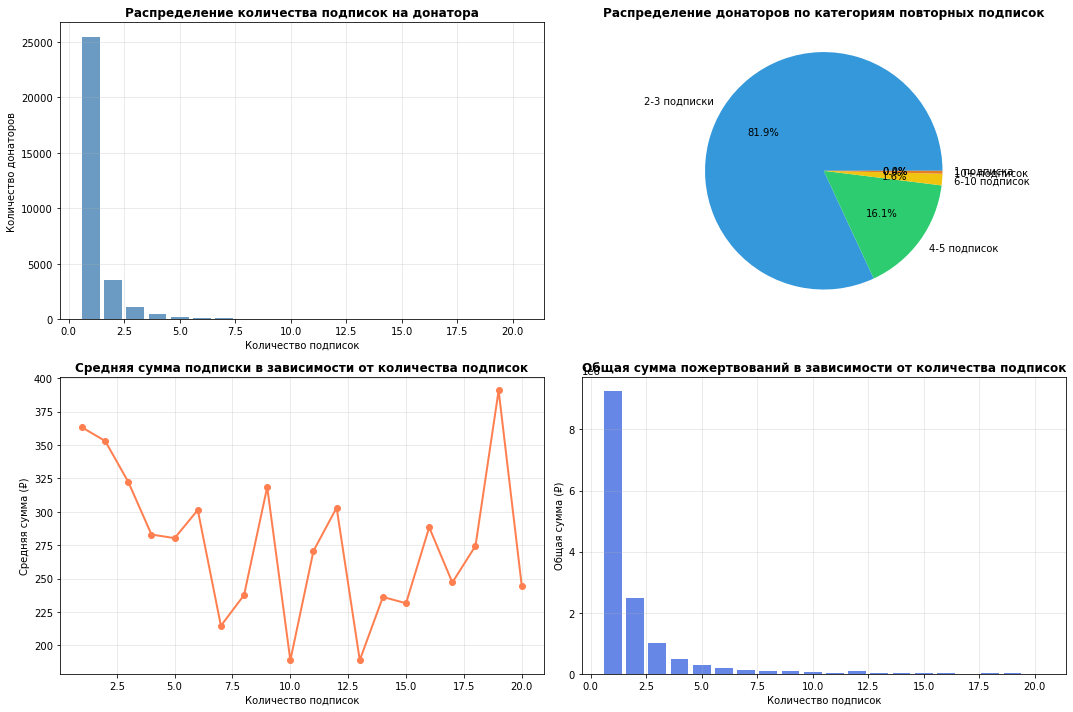

In [63]:
# --- Задача 11: Исследование повторных пожертвований ---

print("--- Исследование повторных пожертвований ---")

# --- 11.1 Анализ повторных пожертвований ---

print("\n--- 11.1 Анализ повторных пожертвований ---")

# Определяем донаторов с повторными пожертвованиями
# Группируем по донаторам и считаем количество подписок
donor_subscriptions = df.groupby('ID плательщика').agg({
    'ID': 'count',
    'Сумма': ['sum', 'mean', 'min', 'max'],
    'Дата/время создания': ['min', 'max']
}).reset_index()

donor_subscriptions.columns = ['ID плательщика', 'Количество_подписок', 'Общая_сумма', 
                               'Средняя_сумма', 'Минимальная_сумма', 'Максимальная_сумма',
                               'Первая_подписка', 'Последняя_подписка']

# Категоризация донаторов по количеству подписок
donor_subscriptions['Категория_повторных'] = pd.cut(
    donor_subscriptions['Количество_подписок'],
    bins=[0, 1, 2, 5, 10, float('inf')],
    labels=['1 подписка', '2-3 подписки', '4-5 подписок', '6-10 подписок', '10+ подписок'],
    right=False
)

# Статистика по категориям
repeat_stats = donor_subscriptions.groupby('Категория_повторных').agg({
    'ID плательщика': 'count',
    'Общая_сумма': ['sum', 'mean', 'median'],
    'Количество_подписок': ['mean', 'median']
}).round(2)

repeat_stats.columns = ['Количество_донаторов', 'Общая_сумма', 'Средняя_сумма', 'Медианная_сумма',
                        'Среднее_подписок', 'Медианное_подписок']

print("Распределение донаторов по количеству подписок:")
display(repeat_stats)

# Доля донаторов с повторными подписками
donors_with_repeat = donor_subscriptions[donor_subscriptions['Количество_подписок'] > 1].shape[0]
repeat_rate = donors_with_repeat / total_donors * 100

print(f"\nДоля донаторов с повторными подписками: {repeat_rate:.1f}%")
print(f"  - Всего донаторов: {total_donors}")
print(f"  - Донаторов с >1 подпиской: {donors_with_repeat}")

# Визуализация распределения повторных подписок
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Распределение количества подписок на донатора
ax1 = axes[0, 0]
sub_count_dist = donor_subscriptions['Количество_подписок'].value_counts().sort_index()
sub_count_dist = sub_count_dist[sub_count_dist.index <= 20]  # ограничиваем для наглядности
ax1.bar(sub_count_dist.index, sub_count_dist.values, color='steelblue', alpha=0.8)
ax1.set_title('Распределение количества подписок на донатора', fontsize=12, fontweight='bold')
ax1.set_xlabel('Количество подписок')
ax1.set_ylabel('Количество донаторов')
ax1.grid(True, alpha=0.3)

# 2. Категории повторных подписок
ax2 = axes[0, 1]
repeat_cat_counts = donor_subscriptions['Категория_повторных'].value_counts()
colors_cat = ['#3498db', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
ax2.pie(repeat_cat_counts.values, labels=repeat_cat_counts.index, autopct='%1.1f%%', 
        colors=colors_cat[:len(repeat_cat_counts)])
ax2.set_title('Распределение донаторов по категориям повторных подписок', fontsize=12, fontweight='bold')

# 3. Средняя сумма в зависимости от количества подписок
ax3 = axes[1, 0]
avg_by_sub_count = donor_subscriptions.groupby('Количество_подписок')['Средняя_сумма'].mean()
avg_by_sub_count = avg_by_sub_count[avg_by_sub_count.index <= 20]
ax3.plot(avg_by_sub_count.index, avg_by_sub_count.values, marker='o', color='coral', linewidth=2)
ax3.set_title('Средняя сумма подписки в зависимости от количества подписок', fontsize=12, fontweight='bold')
ax3.set_xlabel('Количество подписок')
ax3.set_ylabel('Средняя сумма (₽)')
ax3.grid(True, alpha=0.3)

# 4. Общая сумма в зависимости от количества подписок
ax4 = axes[1, 1]
total_by_sub_count = donor_subscriptions.groupby('Количество_подписок')['Общая_сумма'].sum()
total_by_sub_count = total_by_sub_count[total_by_sub_count.index <= 20]
ax4.bar(total_by_sub_count.index, total_by_sub_count.values, color='royalblue', alpha=0.8)
ax4.set_title('Общая сумма пожертвований в зависимости от количества подписок', fontsize=12, fontweight='bold')
ax4.set_xlabel('Количество подписок')
ax4.set_ylabel('Общая сумма (₽)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--- 11.2 Интервалы между платежами ---
Всего интервалов между подписками: 11701

Статистика интервалов между подписками:
  Средний интервал: 158.4 дней
  Медианный интервал: 59.0 дней
  Минимальный интервал: 0.0 дней
  Максимальный интервал: 2630.0 дней

  Квартили:
    25-й перцентиль: 10.0 дней
    50-й перцентиль (медиана): 59.0 дней
    75-й перцентиль: 192.0 дней


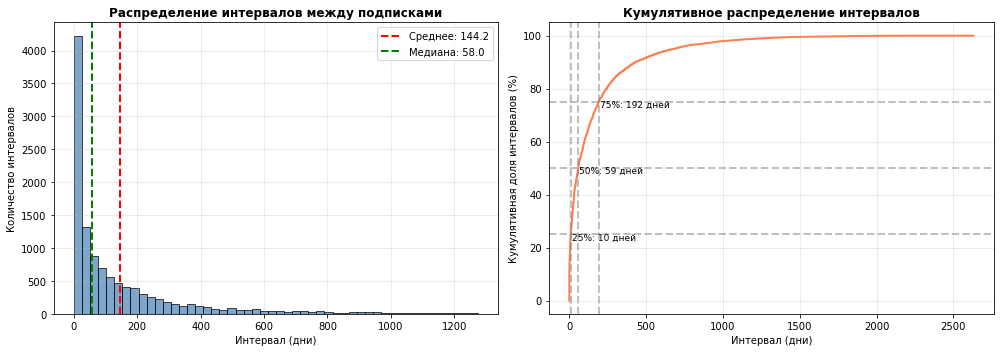

In [64]:
# --- 11.2 Интервалы между платежами ---

print("\n--- 11.2 Интервалы между платежами ---")

# Для расчета интервалов между платежами нам нужно отсортировать подписки для каждого донатора
# и рассчитать разницу между датами создания

# Сортируем данные по донатору и дате
df_sorted = df.sort_values(['ID плательщика', 'Дата/время создания'])

# Для каждого донатора рассчитываем интервалы между подписками
intervals = []

for donor in df_sorted['ID плательщика'].unique():
    donor_data = df_sorted[df_sorted['ID плательщика'] == donor]
    if len(donor_data) > 1:
        dates = donor_data['Дата/время создания'].values
        for i in range(1, len(dates)):
            # Исправление: правильно извлекаем количество дней из timedelta64
            interval = (dates[i] - dates[i-1]).astype('timedelta64[D]').astype(int)
            intervals.append(interval)

# Создаем датафрейм с интервалами
intervals_df = pd.DataFrame({'Интервал_дней': intervals})

print(f"Всего интервалов между подписками: {len(intervals_df)}")

if len(intervals_df) > 0:
    print(f"\nСтатистика интервалов между подписками:")
    print(f"  Средний интервал: {intervals_df['Интервал_дней'].mean():.1f} дней")
    print(f"  Медианный интервал: {intervals_df['Интервал_дней'].median():.1f} дней")
    print(f"  Минимальный интервал: {intervals_df['Интервал_дней'].min():.1f} дней")
    print(f"  Максимальный интервал: {intervals_df['Интервал_дней'].max():.1f} дней")
    
    # Квартили
    quartiles = intervals_df['Интервал_дней'].quantile([0.25, 0.5, 0.75])
    print(f"\n  Квартили:")
    print(f"    25-й перцентиль: {quartiles[0.25]:.1f} дней")
    print(f"    50-й перцентиль (медиана): {quartiles[0.5]:.1f} дней")
    print(f"    75-й перцентиль: {quartiles[0.75]:.1f} дней")
else:
    print("\nНет интервалов для анализа (все донаторы имеют только одну подписку)")

# Визуализация интервалов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Гистограмма интервалов
ax1 = axes[0]
if len(intervals_df) > 0:
    # Ограничиваем для наглядности (99-й перцентиль)
    max_interval = intervals_df['Интервал_дней'].quantile(0.99)
    filtered_intervals = intervals_df[intervals_df['Интервал_дней'] <= max_interval]
    ax1.hist(filtered_intervals['Интервал_дней'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.axvline(filtered_intervals['Интервал_дней'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Среднее: {filtered_intervals["Интервал_дней"].mean():.1f}')
    ax1.axvline(filtered_intervals['Интервал_дней'].median(), color='green', linestyle='--', 
                linewidth=2, label=f'Медиана: {filtered_intervals["Интервал_дней"].median():.1f}')
    ax1.set_title('Распределение интервалов между подписками', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Интервал (дни)')
    ax1.set_ylabel('Количество интервалов')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'Нет данных для визуализации', 
             horizontalalignment='center', verticalalignment='center',
             transform=ax1.transAxes, fontsize=14)
    
# 2. Кумулятивная доля интервалов
ax2 = axes[1]
if len(intervals_df) > 0:
    intervals_sorted = intervals_df['Интервал_дней'].sort_values()
    cumulative_pct = np.arange(1, len(intervals_sorted) + 1) / len(intervals_sorted) * 100
    ax2.plot(intervals_sorted.values, cumulative_pct, color='coral', linewidth=2)
    ax2.set_title('Кумулятивное распределение интервалов', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Интервал (дни)')
    ax2.set_ylabel('Кумулятивная доля интервалов (%)')
    ax2.grid(True, alpha=0.3)
    
    # Добавляем отметки для ключевых процентов
    for pct in [25, 50, 75]:
        idx = int(len(intervals_sorted) * pct / 100)
        if idx < len(intervals_sorted):
            interval_at_pct = intervals_sorted.iloc[idx]
            ax2.axhline(y=pct, color='gray', linestyle='--', alpha=0.5)
            ax2.axvline(x=interval_at_pct, color='gray', linestyle='--', alpha=0.5)
            ax2.text(interval_at_pct + 5, pct - 2, f'{pct}%: {interval_at_pct:.0f} дней', fontsize=9)
else:
    ax2.text(0.5, 0.5, 'Нет данных для визуализации', 
             horizontalalignment='center', verticalalignment='center',
             transform=ax2.transAxes, fontsize=14)

plt.tight_layout()
plt.show()    


--- Анализ интервалов по категориям донаторов ---

Распределение донаторов по среднему интервалу между подписками:
  <1 мес: 931 донаторов (16.5%)
  1-2 мес: 624 донаторов (11.1%)
  2-3 мес: 557 донаторов (9.9%)
  3-6 мес: 1136 донаторов (20.2%)
  >6 мес: 2118 донаторов (37.6%)


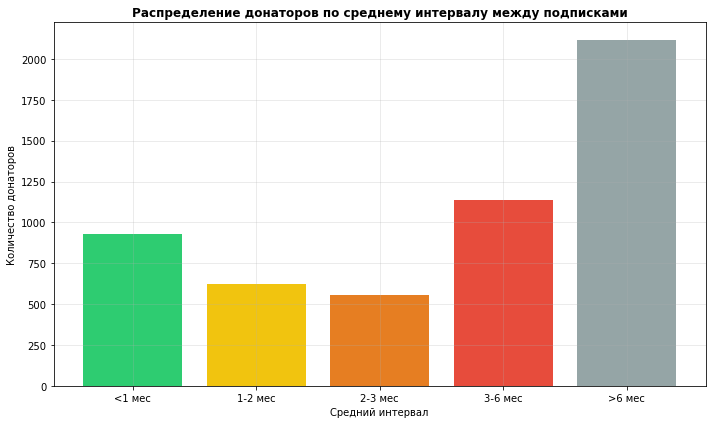

In [65]:
# Дополнительный анализ: интервалы по категориям донаторов
if len(intervals_df) > 0:
    print("\n--- Анализ интервалов по категориям донаторов ---")
    
    # Создаем категории на основе среднего интервала для каждого донатора
    donor_intervals = []
    for donor in df_sorted['ID плательщика'].unique():
        donor_data = df_sorted[df_sorted['ID плательщика'] == donor]
        if len(donor_data) > 1:
            dates = donor_data['Дата/время создания'].values
            donor_intervals_list = []
            for i in range(1, len(dates)):
                interval = (dates[i] - dates[i-1]).astype('timedelta64[D]').astype(int)
                donor_intervals_list.append(interval)
            if donor_intervals_list:
                donor_intervals.append({
                    'ID плательщика': donor,
                    'средний_интервал': np.mean(donor_intervals_list),
                    'мин_интервал': np.min(donor_intervals_list),
                    'макс_интервал': np.max(donor_intervals_list),
                    'количество_интервалов': len(donor_intervals_list)
                })
    
    if donor_intervals:
        donor_intervals_df = pd.DataFrame(donor_intervals)
        
        # Категоризация по среднему интервалу
        donor_intervals_df['Категория_интервала'] = pd.cut(
            donor_intervals_df['средний_интервал'],
            bins=[0, 30, 60, 90, 180, float('inf')],
            labels=['<1 мес', '1-2 мес', '2-3 мес', '3-6 мес', '>6 мес']
        )
        
        print("\nРаспределение донаторов по среднему интервалу между подписками:")
        interval_category_counts = donor_intervals_df['Категория_интервала'].value_counts().sort_index()
        for category, count in interval_category_counts.items():
            pct = count / len(donor_intervals_df) * 100
            print(f"  {category}: {count} донаторов ({pct:.1f}%)")
        
        # Визуализация категорий интервалов
        fig, ax = plt.subplots(figsize=(10, 6))
        colors_interval = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#95a5a6']
        ax.bar(interval_category_counts.index, interval_category_counts.values, 
               color=colors_interval[:len(interval_category_counts)])
        ax.set_title('Распределение донаторов по среднему интервалу между подписками', 
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Средний интервал')
        ax.set_ylabel('Количество донаторов')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


--- 11.3 Жизненный цикл донатора ---
Статистика продолжительности жизни донатора:
  Средняя продолжительность: 59.7 дней (2.0 мес)
  Медианная продолжительность: 0.0 дней (0.0 мес)
  Максимальная продолжительность: 2630.0 дней (86.4 мес)

Распределение донаторов по продолжительности жизни:


,Количество_донаторов,Общая_сумма,Средняя_сумма,Медианная_сумма,Среднее_подписок,Медианное_подписок
Категория_жизни,,,,,,
<1 мес,26499,9966007.82,376.09,200.0,1.05,1.0
1-3 мес,722,503190.89,696.94,400.0,2.39,2.0
3-6 мес,869,801788.00,922.66,400.0,2.58,2.0
6-12 мес,1304,1256268.07,963.40,500.0,3.50,2.0
1-2 года,972,1034570.00,1064.37,600.0,3.63,3.0
2+ лет,739,931673.00,1260.72,700.0,4.12,3.0


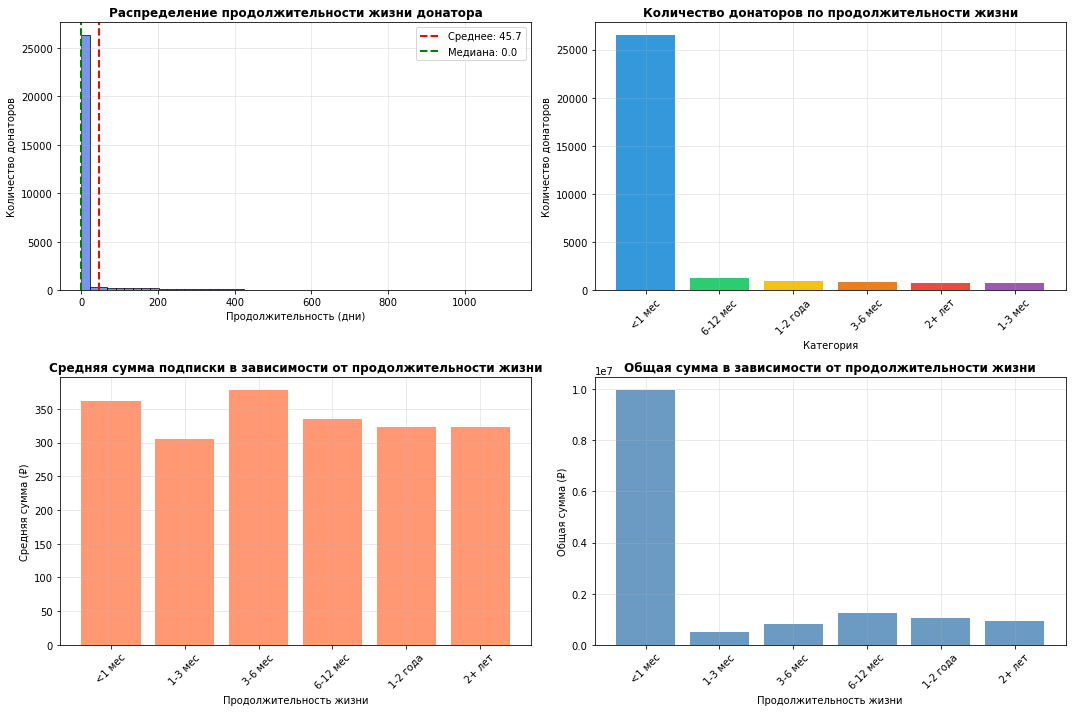


--- Ключевые выводы по жизненному циклу донаторов ---
  <1 мес: 26499 донаторов (85.2%)
  1-3 мес: 722 донаторов (2.3%)
  3-6 мес: 869 донаторов (2.8%)
  6-12 мес: 1304 донаторов (4.2%)
  1-2 года: 972 донаторов (3.1%)
  2+ лет: 739 донаторов (2.4%)

⚠️ Низкая продолжительность жизни донатора (<3 месяцев)


In [66]:
# --- 11.3 Жизненный цикл донатора ---

print("\n--- 11.3 Жизненный цикл донатора ---")

# Рассчитываем продолжительность жизни донатора (от первой до последней подписки)
donor_lifetime = donor_subscriptions.copy()
donor_lifetime['Продолжительность_дней'] = (donor_lifetime['Последняя_подписка'] - donor_lifetime['Первая_подписка']).dt.days
donor_lifetime['Продолжительность_месяцев'] = donor_lifetime['Продолжительность_дней'] / 30.44

# Для донаторов с одной подпиской продолжительность = 0
donor_lifetime['Продолжительность_дней'] = donor_lifetime['Продолжительность_дней'].clip(lower=0)

print(f"Статистика продолжительности жизни донатора:")
print(f"  Средняя продолжительность: {donor_lifetime['Продолжительность_дней'].mean():.1f} дней ({donor_lifetime['Продолжительность_дней'].mean()/30.44:.1f} мес)")
print(f"  Медианная продолжительность: {donor_lifetime['Продолжительность_дней'].median():.1f} дней ({donor_lifetime['Продолжительность_дней'].median()/30.44:.1f} мес)")
print(f"  Максимальная продолжительность: {donor_lifetime['Продолжительность_дней'].max():.1f} дней ({donor_lifetime['Продолжительность_дней'].max()/30.44:.1f} мес)")

# Категоризация по продолжительности жизни
# 7 границ -> 6 интервалов -> 6 меток
donor_lifetime['Категория_жизни'] = pd.cut(
    donor_lifetime['Продолжительность_месяцев'],
    bins=[0, 1, 3, 6, 12, 24, float('inf')],
    labels=['<1 мес', '1-3 мес', '3-6 мес', '6-12 мес', '1-2 года', '2+ лет'],
    right=False
)

lifetime_cat_stats = donor_lifetime.groupby('Категория_жизни', observed=True).agg({
    'ID плательщика': 'count',
    'Общая_сумма': ['sum', 'mean', 'median'],
    'Количество_подписок': ['mean', 'median']
}).round(2)

lifetime_cat_stats.columns = ['Количество_донаторов', 'Общая_сумма', 'Средняя_сумма', 'Медианная_сумма',
                              'Среднее_подписок', 'Медианное_подписок']

print("\nРаспределение донаторов по продолжительности жизни:")
display(lifetime_cat_stats)

# Визуализация жизненного цикла
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Распределение продолжительности жизни
ax1 = axes[0, 0]
# Ограничиваем для наглядности (99-й перцентиль)
max_lifetime = donor_lifetime['Продолжительность_дней'].quantile(0.99)
filtered_lifetime = donor_lifetime[donor_lifetime['Продолжительность_дней'] <= max_lifetime]
ax1.hist(filtered_lifetime['Продолжительность_дней'], bins=50, color='royalblue', alpha=0.7, edgecolor='black')
ax1.axvline(filtered_lifetime['Продолжительность_дней'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Среднее: {filtered_lifetime["Продолжительность_дней"].mean():.1f}')
ax1.axvline(filtered_lifetime['Продолжительность_дней'].median(), color='green', linestyle='--', 
            linewidth=2, label=f'Медиана: {filtered_lifetime["Продолжительность_дней"].median():.1f}')
ax1.set_title('Распределение продолжительности жизни донатора', fontsize=12, fontweight='bold')
ax1.set_xlabel('Продолжительность (дни)')
ax1.set_ylabel('Количество донаторов')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Категории продолжительности жизни
ax2 = axes[0, 1]
lifetime_cat_counts = donor_lifetime['Категория_жизни'].value_counts()
colors_life = ['#3498db', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6']
ax2.bar(lifetime_cat_counts.index, lifetime_cat_counts.values, 
        color=colors_life[:len(lifetime_cat_counts)])
ax2.set_title('Количество донаторов по продолжительности жизни', fontsize=12, fontweight='bold')
ax2.set_xlabel('Категория')
ax2.set_ylabel('Количество донаторов')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# 3. Средняя сумма в зависимости от продолжительности жизни
ax3 = axes[1, 0]
avg_by_lifetime = donor_lifetime.groupby('Категория_жизни', observed=True)['Средняя_сумма'].mean()
ax3.bar(avg_by_lifetime.index, avg_by_lifetime.values, color='coral', alpha=0.8)
ax3.set_title('Средняя сумма подписки в зависимости от продолжительности жизни', fontsize=12, fontweight='bold')
ax3.set_xlabel('Продолжительность жизни')
ax3.set_ylabel('Средняя сумма (₽)')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# 4. Общая сумма в зависимости от продолжительности жизни
ax4 = axes[1, 1]
total_by_lifetime = donor_lifetime.groupby('Категория_жизни', observed=True)['Общая_сумма'].sum()
ax4.bar(total_by_lifetime.index, total_by_lifetime.values, color='steelblue', alpha=0.8)
ax4.set_title('Общая сумма в зависимости от продолжительности жизни', fontsize=12, fontweight='bold')
ax4.set_xlabel('Продолжительность жизни')
ax4.set_ylabel('Общая сумма (₽)')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Выводы по жизненному циклу ---

print("\n--- Ключевые выводы по жизненному циклу донаторов ---")

# Определяем долю донаторов в каждой категории
for category in lifetime_cat_stats.index:
    count = lifetime_cat_stats.loc[category, 'Количество_донаторов']
    pct = count / len(donor_lifetime) * 100
    print(f"  {category}: {count} донаторов ({pct:.1f}%)")

# Выводы
if donor_lifetime['Продолжительность_дней'].median() > 180:
    print("\n✅ Хорошая продолжительность жизни донатора (>6 месяцев)")
elif donor_lifetime['Продолжительность_дней'].median() > 90:
    print("\n⚠️ Средняя продолжительность жизни донатора (3-6 месяцев)")
else:
    print("\n⚠️ Низкая продолжительность жизни донатора (<3 месяцев)")


--- 11.4 Анализ переходов между статусами ---
Матрица переходов между статусами подписок:


В_статус,Активна,В ожидании,Отклонена,Отменена,Просрочена
Из_статуса,,,,,
Активна,576,2,100,88,50
В ожидании,1,0,1,0,1
Отклонена,376,3,3968,818,125
Отменена,283,1,855,3968,60
Просрочена,60,0,56,25,284


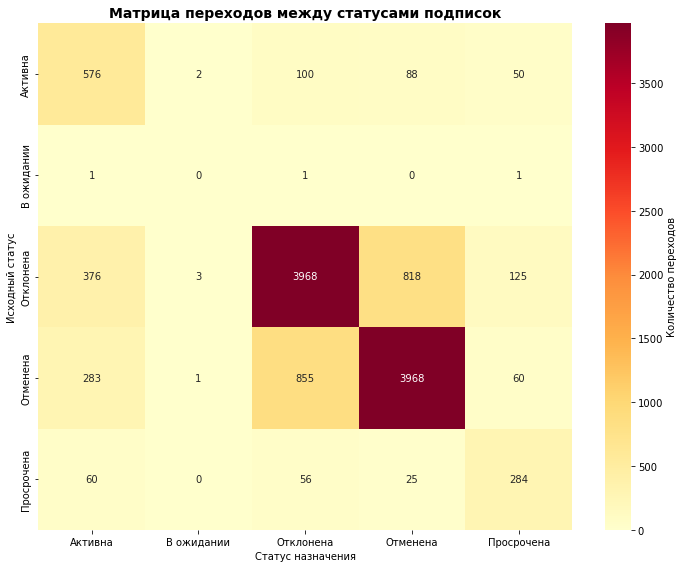

In [67]:
# --- 11.4 Анализ переходов между статусами ---

print("\n--- 11.4 Анализ переходов между статусами ---")

# Создаем матрицу переходов между статусами для подписок
# Для этого нам нужно отследить, как меняется статус подписок со временем

# Группируем по донатору и сортируем по дате
df_sorted = df.sort_values(['ID плательщика', 'Дата/время создания'])

# Для каждого донатора определяем последовательность статусов
transitions = []
for donor in df_sorted['ID плательщика'].unique():
    donor_data = df_sorted[df_sorted['ID плательщика'] == donor]
    statuses = donor_data['Статус'].values
    for i in range(len(statuses) - 1):
        transitions.append((statuses[i], statuses[i+1]))

# Создаем матрицу переходов
transition_df = pd.DataFrame(transitions, columns=['Из_статуса', 'В_статус'])
transition_matrix = pd.crosstab(transition_df['Из_статуса'], transition_df['В_статус'])

print("Матрица переходов между статусами подписок:")
display(transition_matrix)

# Визуализация матрицы переходов
plt.figure(figsize=(10, 8))
sns.heatmap(transition_matrix, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Количество переходов'})
plt.title('Матрица переходов между статусами подписок', fontsize=14, fontweight='bold')
plt.xlabel('Статус назначения')
plt.ylabel('Исходный статус')
plt.tight_layout()
plt.show()

In [68]:
# --- 11.5 Ключевые выводы ---

print("\n" + "="*60)
print("ИТОГОВЫЕ ВЫВОДЫ ПО ПОВТОРНЫМ ПОЖЕРТВОВАНИЯМ")
print("="*60)

print(f"\n1. Повторные пожертвования:")
print(f"   - Доля донаторов с повторными подписками: {repeat_rate:.1f}%")
print(f"   - Среднее количество подписок на донатора: {donor_subscriptions['Количество_подписок'].mean():.2f}")
print(f"   - Медианное количество подписок на донатора: {donor_subscriptions['Количество_подписок'].median():.0f}")

print(f"\n2. Интервалы между подписками:")
if len(intervals_df) > 0:
    print(f"   - Средний интервал: {intervals_df['Интервал_дней'].mean():.1f} дней")
    print(f"   - Медианный интервал: {intervals_df['Интервал_дней'].median():.1f} дней")
    print(f"   - 75% интервалов менее {quartiles[0.75]:.1f} дней")

print(f"\n3. Жизненный цикл донатора:")
print(f"   - Средняя продолжительность жизни: {donor_lifetime['Продолжительность_дней'].mean():.1f} дней ({donor_lifetime['Продолжительность_дней'].mean()/30.44:.1f} мес)")
print(f"   - Медианная продолжительность жизни: {donor_lifetime['Продолжительность_дней'].median():.1f} дней ({donor_lifetime['Продолжительность_дней'].median()/30.44:.1f} мес)")

# Распределение по категориям жизни
if len(lifetime_cat_stats) > 0:
    print(f"\n4. Распределение по продолжительности жизни:")
    for category in lifetime_cat_stats.index:
        count = lifetime_cat_stats.loc[category, 'Количество_донаторов']
        pct = count / total_donors * 100
        print(f"   - {category}: {count} донаторов ({pct:.1f}%)")

print("\n5. Ключевые инсайты:")

# Интерпретация результатов
if repeat_rate > 30:
    print("   ✅ Хороший показатель повторных пожертвований (>30%)")
else:
    print("   ⚠️ Низкий показатель повторных пожертвований (<30%)")

if len(intervals_df) > 0 and intervals_df['Интервал_дней'].median() < 45:
    print("   ✅ Донаторы возвращаются быстро (медианный интервал < 45 дней)")
elif len(intervals_df) > 0 and intervals_df['Интервал_дней'].median() < 90:
    print("   ⚠️ Донаторы возвращаются с умеренной скоростью (медианный интервал 45-90 дней)")
elif len(intervals_df) > 0:
    print("   ⚠️ Донаторы возвращаются медленно (медианный интервал > 90 дней)")

if donor_lifetime['Продолжительность_дней'].median() > 180:
    print("   ✅ Хорошая продолжительность жизни донатора (>6 месяцев)")
elif donor_lifetime['Продолжительность_дней'].median() > 90:
    print("   ⚠️ Средняя продолжительность жизни донатора (3-6 месяцев)")
else:
    print("   ⚠️ Низкая продолжительность жизни донатора (<3 месяцев)")

print("\n6. Рекомендации:")
print("   📈 Для увеличения повторных пожертвований:")
print("      - Создать программу лояльности для донаторов с >3 подписками")
print("      - Отправлять напоминания донаторам, у которых давно не было подписок")
print("      - Предлагать годовую подписку с преимуществами")
print("   📊 Для увеличения продолжительности жизни:")
print("      - Улучшить коммуникацию в первые 3 месяца")
print("      - Регулярно информировать о влиянии пожертвований")
print("      - Вовлекать донаторов в жизнь фонда")


ИТОГОВЫЕ ВЫВОДЫ ПО ПОВТОРНЫМ ПОЖЕРТВОВАНИЯМ

1. Повторные пожертвования:
   - Доля донаторов с повторными подписками: 18.1%
   - Среднее количество подписок на донатора: 1.38
   - Медианное количество подписок на донатора: 1

2. Интервалы между подписками:
   - Средний интервал: 158.4 дней
   - Медианный интервал: 59.0 дней
   - 75% интервалов менее 192.0 дней

3. Жизненный цикл донатора:
   - Средняя продолжительность жизни: 59.7 дней (2.0 мес)
   - Медианная продолжительность жизни: 0.0 дней (0.0 мес)

4. Распределение по продолжительности жизни:
   - <1 мес: 26499 донаторов (85.2%)
   - 1-3 мес: 722 донаторов (2.3%)
   - 3-6 мес: 869 донаторов (2.8%)
   - 6-12 мес: 1304 донаторов (4.2%)
   - 1-2 года: 972 донаторов (3.1%)
   - 2+ лет: 739 донаторов (2.4%)

5. Ключевые инсайты:
   ⚠️ Низкий показатель повторных пожертвований (<30%)
   ⚠️ Донаторы возвращаются с умеренной скоростью (медианный интервал 45-90 дней)
   ⚠️ Низкая продолжительность жизни донатора (<3 месяцев)

6. Рекоменд

# Итоговые выводы и рекомендации

## 1. Увеличение регулярных пожертвований

**Проблема:** Все подписки являются регулярными (периодичность "Раз в месяц"), но общая доля активных подписок составляет всего 15.1%.

**Рекомендация:** Сделать процесс оформления подписки максимально простым и быстрым. Использовать ясные call-to-action (призывы к действию), подчеркивая удобство и системность ежемесячной помощи.

## 2. Повышение удержания донаторов

**Проблема:** Первый месяц критичен. Уровень оттока (Churn Rate) высокий — 84.8%. Retention (удержание) через 1 месяц падает до 2.5%, а через 12 месяцев — до 0.6%.

**Рекомендация:**

- Welcome-кампания: В первый месяц активно вовлекать донаторов, показывать им результаты их помощи.

- Коммуникация: Информировать донаторов о влиянии их пожертвований на проекты фонда.

- Анти-отток: Разработать re-engagement-кампании для донаторов в сегментах "Ценные, но уходящие (At Risk)" и "Уходящие (About to Churn)", чтобы вернуть их внимание и побудить к действию.

## 3. Увеличение средней продолжительности подписки

**Проблема:** Медианная длительность подписки составляет всего 1 месяц (30 дней), а медианное время жизни подписки по Survival Analysis — 95 месяцев, что указывает на нестабильность или наличие редких, но очень долгих подписок.

**Рекомендация:**

- Программа лояльности: Предоставлять бонусы или особый статус донаторам, чья подписка активна 3, 6 и 12 месяцев.

- Эксклюзивный контент: Создать для подписчиков закрытые материалы: видео-отчеты, интервью с подопечными, чтобы укрепить эмоциональную связь с фондом.

## 4. Рост долгосрочной ценности донатора (LTV)

**Проблема:** 25% донаторов (в основном "Супер-донаторы") генерируют основную долю пожертвований. Средний LTV составляет 465.95 ₽, а средняя сумма на донатора в первом месяце — 358.22 ₽.

**Рекомендация:**

- Персонализация: Использовать RFM-сегменты для адаптации коммуникаций и предложений.

- Развитие ключевых сегментов: Сфокусировать усилия на "Супер-донаторах (Champions)", вовлекая их как амбассадоров, и активно работать с "Лояльными донаторами (Loyal)", чтобы перевести их в категорию супер-донаторов.

- Восстановление "спящих": Разработать специальные стратегии для сегмента "Потерянные донаторы (Lost)", чтобы попытаться вернуть их с помощью обновленной информации о деятельности фонда.